# Momentum + Multi-Factor Equity Strategy
### S&P 500 Universe | Monthly Rebalance | 2010–Present

This notebook builds and validates a systematic long-only equity strategy that combines four well-documented return factors (Momentum, Value, Quality, and Low Volatility) applied monthly across a approx 200-stock S&P 500 universe. The composite signal is cross-sectionally z-scored, and the top 20% is held equally weighted with monthly rebalancing and realistic transaction costs.

The analysis follows a  validation sequence designed to separate genuine signal from overfitting: in-sample calibration ends at 2018, and all parameters are frozen before the out-of-sample period begins. Walk-forward analysis and block-bootstrap Monte Carlo then stress-test robustness across rolling windows and resampled return paths.

**Limitations:** The fundamental data prior to mid-2021 is a static snapshot which introduces look-ahead bias in the Value and Quality factors. The universe is also drawn from the current S&P 500 constituent list, not a historical one, adding survivorship bias. Together these likely inflate reported returns by 1–3% p.a. The price-based factors (Momentum, Low Vol) rest on cleaner foundations and are the more defensible sources of alpha.

**Validation pipeline:**

| Step | Period | Purpose |
|------|--------|---------|
| In-Sample | 2010–2018 | Parameter selection and factor calibration |
| Out-of-Sample | 2019–Present | Primary performance test |
| Walk-Forward | Rolling 3Y windows | Sharpe stability across regimes |
| Monte Carlo | Block bootstrap × 5,000 | Outcome distribution and downside quantiles |
| Attribution | Single-factor portfolios | Identify which factors are actually pulling weight |

## 0. Environment Setup

In [72]:
import warnings
warnings.filterwarnings('ignore')

import os, time, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from tqdm import tqdm
import yfinance as yf

# ── Plot aesthetics ──
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
COLORS = {
    'strategy':  '#2563EB',
    'benchmark': '#DC2626',
    'neutral':   '#6B7280',
    'positive':  '#16A34A',
    'negative':  '#DC2626',
}

# ── Global config ──
START_DATE     = '2009-01-01'
IS_END_DATE    = '2018-12-31'
OOS_START_DATE = '2019-01-01'
END_DATE       = datetime.today().strftime('%Y-%m-%d')

TOP_QUINTILE     = 0.20
TRANSACTION_COST = 0.0010   # 10 bps one-way
RISK_FREE_RATE   = 0.04     # annualised, used for Sharpe / Sortino
N_MONTE_CARLO    = 5000
RANDOM_SEED      = 42

# Momentum carries the heaviest weight; low vol is a diversifier, not a primary bet
FACTOR_WEIGHTS = {
    'momentum': 0.35,
    'value':    0.25,
    'quality':  0.25,
    'low_vol':  0.15,
}
assert abs(sum(FACTOR_WEIGHTS.values()) - 1.0) < 1e-9, "Factor weights must sum to 1"

CACHE_DIR = Path('data_cache')
CACHE_DIR.mkdir(exist_ok=True)

np.random.seed(RANDOM_SEED)

## 1. Universe Construction — S&P 500 Tickers

200 large-cap constituents drawn from the current S&P 500 list. This is a static snapshot, which means companies added to the index after 2010 are back-filled into the universe, and companies deleted through bankruptcy or acquisition are excluded. Both effects bias returns upward.

In [73]:
def get_sp500_tickers() -> pd.DataFrame:
    """Hardcoded list of ~200 major S&P 500 constituents."""
    tickers_data = [
        # Info Tech
        ('AAPL', 'Apple Inc.', 'Information Technology'),
        ('MSFT', 'Microsoft', 'Information Technology'),
        ('NVDA', 'Nvidia', 'Information Technology'),
        ('AVGO', 'Broadcom', 'Information Technology'),
        ('ORCL', 'Oracle', 'Information Technology'),
        ('CRM', 'Salesforce', 'Information Technology'),
        ('AMD', 'Advanced Micro Devices', 'Information Technology'),
        ('AMAT', 'Applied Materials', 'Information Technology'),
        ('ADI', 'Analog Devices', 'Information Technology'),
        ('KLAC', 'KLA Corporation', 'Information Technology'),
        ('LRCX', 'Lam Research', 'Information Technology'),
        ('INTC', 'Intel', 'Information Technology'),
        ('MU', 'Micron Technology', 'Information Technology'),
        ('QCOM', 'Qualcomm', 'Information Technology'),
        ('TXN', 'Texas Instruments', 'Information Technology'),
        ('CSCO', 'Cisco', 'Information Technology'),
        ('IBM', 'IBM', 'Information Technology'),
        ('NOW', 'ServiceNow', 'Information Technology'),
        ('INTU', 'Intuit', 'Information Technology'),
        ('ADBE', 'Adobe', 'Information Technology'),
        ('PANW', 'Palo Alto Networks', 'Information Technology'),
        ('CRWD', 'CrowdStrike', 'Information Technology'),
        ('FTNT', 'Fortinet', 'Information Technology'),
        ('SNPS', 'Synopsys', 'Information Technology'),
        ('CDNS', 'Cadence Design Systems', 'Information Technology'),
        ('HPQ', 'HP Inc.', 'Information Technology'),
        ('HPE', 'Hewlett Packard Enterprise', 'Information Technology'),
        ('GLW', 'Corning', 'Information Technology'),
        ('TEL', 'TE Connectivity', 'Information Technology'),
        ('APH', 'Amphenol', 'Information Technology'),
        # Communication Services
        ('GOOGL', 'Alphabet Class A', 'Communication Services'),
        ('GOOG', 'Alphabet Class C', 'Communication Services'),
        ('META', 'Meta Platforms', 'Communication Services'),
        ('NFLX', 'Netflix', 'Communication Services'),
        ('DIS', 'Walt Disney', 'Communication Services'),
        ('CMCSA', 'Comcast', 'Communication Services'),
        ('T', 'AT&T', 'Communication Services'),
        ('VZ', 'Verizon', 'Communication Services'),
        ('TMUS', 'T-Mobile US', 'Communication Services'),
        ('EA', 'Electronic Arts', 'Communication Services'),
        ('TTWO', 'Take-Two Interactive', 'Communication Services'),
        ('OMC', 'Omnicom Group', 'Communication Services'),
        ('WBD', 'Warner Bros Discovery', 'Communication Services'),
        ('CHTR', 'Charter Communications', 'Communication Services'),
        # Consumer Discretionary
        ('AMZN', 'Amazon', 'Consumer Discretionary'),
        ('TSLA', 'Tesla', 'Consumer Discretionary'),
        ('HD', 'Home Depot', 'Consumer Discretionary'),
        ('MCD', 'McDonalds', 'Consumer Discretionary'),
        ('NKE', 'Nike', 'Consumer Discretionary'),
        ('LOW', "Lowe's", 'Consumer Discretionary'),
        ('SBUX', 'Starbucks', 'Consumer Discretionary'),
        ('TJX', 'TJX Companies', 'Consumer Discretionary'),
        ('BKNG', 'Booking Holdings', 'Consumer Discretionary'),
        ('CMG', 'Chipotle', 'Consumer Discretionary'),
        ('GM', 'General Motors', 'Consumer Discretionary'),
        ('F', 'Ford Motor', 'Consumer Discretionary'),
        ('EBAY', 'eBay', 'Consumer Discretionary'),
        ('MAR', 'Marriott', 'Consumer Discretionary'),
        ('HLT', 'Hilton', 'Consumer Discretionary'),
        ('RCL', 'Royal Caribbean', 'Consumer Discretionary'),
        ('DHI', 'D.R. Horton', 'Consumer Discretionary'),
        ('LEN', 'Lennar', 'Consumer Discretionary'),
        ('ROST', 'Ross Stores', 'Consumer Discretionary'),
        ('ORLY', "O'Reilly Automotive", 'Consumer Discretionary'),
        # Consumer Staples
        ('WMT', 'Walmart', 'Consumer Staples'),
        ('COST', 'Costco', 'Consumer Staples'),
        ('PG', 'Procter & Gamble', 'Consumer Staples'),
        ('KO', 'Coca-Cola', 'Consumer Staples'),
        ('PEP', 'PepsiCo', 'Consumer Staples'),
        ('PM', 'Philip Morris', 'Consumer Staples'),
        ('MO', 'Altria', 'Consumer Staples'),
        ('MDLZ', 'Mondelez', 'Consumer Staples'),
        ('CL', 'Colgate-Palmolive', 'Consumer Staples'),
        ('KMB', 'Kimberly-Clark', 'Consumer Staples'),
        ('GIS', 'General Mills', 'Consumer Staples'),
        ('KR', 'Kroger', 'Consumer Staples'),
        ('SYY', 'Sysco', 'Consumer Staples'),
        ('HSY', 'Hershey', 'Consumer Staples'),
        ('STZ', 'Constellation Brands', 'Consumer Staples'),
        # Health Care
        ('LLY', 'Eli Lilly', 'Health Care'),
        ('UNH', 'UnitedHealth Group', 'Health Care'),
        ('JNJ', 'Johnson & Johnson', 'Health Care'),
        ('MRK', 'Merck', 'Health Care'),
        ('ABBV', 'AbbVie', 'Health Care'),
        ('ABT', 'Abbott Laboratories', 'Health Care'),
        ('TMO', 'Thermo Fisher', 'Health Care'),
        ('DHR', 'Danaher', 'Health Care'),
        ('BMY', 'Bristol-Myers Squibb', 'Health Care'),
        ('AMGN', 'Amgen', 'Health Care'),
        ('ISRG', 'Intuitive Surgical', 'Health Care'),
        ('SYK', 'Stryker', 'Health Care'),
        ('GILD', 'Gilead Sciences', 'Health Care'),
        ('VRTX', 'Vertex Pharmaceuticals', 'Health Care'),
        ('REGN', 'Regeneron', 'Health Care'),
        ('BSX', 'Boston Scientific', 'Health Care'),
        ('MDT', 'Medtronic', 'Health Care'),
        ('PFE', 'Pfizer', 'Health Care'),
        ('CVS', 'CVS Health', 'Health Care'),
        ('CI', 'Cigna', 'Health Care'),
        ('ELV', 'Elevance Health', 'Health Care'),
        ('HCA', 'HCA Healthcare', 'Health Care'),
        ('IDXX', 'Idexx Laboratories', 'Health Care'),
        ('IQV', 'IQVIA', 'Health Care'),
        ('ZBH', 'Zimmer Biomet', 'Health Care'),
        # Financials
        ('BRK-B', 'Berkshire Hathaway', 'Financials'),
        ('JPM', 'JPMorgan Chase', 'Financials'),
        ('BAC', 'Bank of America', 'Financials'),
        ('WFC', 'Wells Fargo', 'Financials'),
        ('MS', 'Morgan Stanley', 'Financials'),
        ('GS', 'Goldman Sachs', 'Financials'),
        ('BLK', 'BlackRock', 'Financials'),
        ('SCHW', 'Charles Schwab', 'Financials'),
        ('AXP', 'American Express', 'Financials'),
        ('V', 'Visa', 'Financials'),
        ('MA', 'Mastercard', 'Financials'),
        ('PYPL', 'PayPal', 'Financials'),
        ('C', 'Citigroup', 'Financials'),
        ('USB', 'U.S. Bancorp', 'Financials'),
        ('PNC', 'PNC Financial', 'Financials'),
        ('TFC', 'Truist Financial', 'Financials'),
        ('COF', 'Capital One', 'Financials'),
        ('ICE', 'Intercontinental Exchange', 'Financials'),
        ('CME', 'CME Group', 'Financials'),
        ('SPGI', 'S&P Global', 'Financials'),
        ('MCO', "Moody's", 'Financials'),
        ('CB', 'Chubb', 'Financials'),
        ('PGR', 'Progressive', 'Financials'),
        ('MMC', 'Marsh McLennan', 'Financials'),
        ('AON', 'Aon', 'Financials'),
        ('AIG', 'American International Group', 'Financials'),
        ('MET', 'MetLife', 'Financials'),
        ('PRU', 'Prudential Financial', 'Financials'),
        ('AMP', 'Ameriprise Financial', 'Financials'),
        ('BX', 'Blackstone', 'Financials'),
        # Industrials
        ('GE', 'GE Aerospace', 'Industrials'),
        ('RTX', 'RTX Corporation', 'Industrials'),
        ('BA', 'Boeing', 'Industrials'),
        ('LMT', 'Lockheed Martin', 'Industrials'),
        ('NOC', 'Northrop Grumman', 'Industrials'),
        ('GD', 'General Dynamics', 'Industrials'),
        ('CAT', 'Caterpillar', 'Industrials'),
        ('DE', 'Deere & Company', 'Industrials'),
        ('UPS', 'United Parcel Service', 'Industrials'),
        ('FDX', 'FedEx', 'Industrials'),
        ('HON', 'Honeywell', 'Industrials'),
        ('ETN', 'Eaton', 'Industrials'),
        ('EMR', 'Emerson Electric', 'Industrials'),
        ('ITW', 'Illinois Tool Works', 'Industrials'),
        ('PH', 'Parker Hannifin', 'Industrials'),
        ('MMM', '3M', 'Industrials'),
        ('GEV', 'GE Vernova', 'Industrials'),
        ('UBER', 'Uber', 'Industrials'),
        ('URI', 'United Rentals', 'Industrials'),
        ('CTAS', 'Cintas', 'Industrials'),
        ('WM', 'Waste Management', 'Industrials'),
        ('RSG', 'Republic Services', 'Industrials'),
        ('DAL', 'Delta Air Lines', 'Industrials'),
        ('UAL', 'United Airlines', 'Industrials'),
        ('CSX', 'CSX Corporation', 'Industrials'),
        ('UNP', 'Union Pacific', 'Industrials'),
        # Energy
        ('XOM', 'ExxonMobil', 'Energy'),
        ('CVX', 'Chevron', 'Energy'),
        ('COP', 'ConocoPhillips', 'Energy'),
        ('EOG', 'EOG Resources', 'Energy'),
        ('SLB', 'SLB', 'Energy'),
        ('MPC', 'Marathon Petroleum', 'Energy'),
        ('PSX', 'Phillips 66', 'Energy'),
        ('VLO', 'Valero Energy', 'Energy'),
        ('OXY', 'Occidental Petroleum', 'Energy'),
        ('HAL', 'Halliburton', 'Energy'),
        ('DVN', 'Devon Energy', 'Energy'),
        ('FANG', 'Diamondback Energy', 'Energy'),
        ('KMI', 'Kinder Morgan', 'Energy'),
        # Materials
        ('LIN', 'Linde', 'Materials'),
        ('APD', 'Air Products', 'Materials'),
        ('SHW', 'Sherwin-Williams', 'Materials'),
        ('ECL', 'Ecolab', 'Materials'),
        ('NEM', 'Newmont', 'Materials'),
        ('FCX', 'Freeport-McMoRan', 'Materials'),
        ('NUE', 'Nucor', 'Materials'),
        ('VMC', 'Vulcan Materials', 'Materials'),
        ('MLM', 'Martin Marietta', 'Materials'),
        ('PPG', 'PPG Industries', 'Materials'),
        # Real Estate
        ('PLD', 'Prologis', 'Real Estate'),
        ('AMT', 'American Tower', 'Real Estate'),
        ('EQIX', 'Equinix', 'Real Estate'),
        ('CCI', 'Crown Castle', 'Real Estate'),
        ('SPG', 'Simon Property Group', 'Real Estate'),
        ('WELL', 'Welltower', 'Real Estate'),
        ('DLR', 'Digital Realty', 'Real Estate'),
        ('PSA', 'Public Storage', 'Real Estate'),
        ('EQR', 'Equity Residential', 'Real Estate'),
        ('AVB', 'AvalonBay Communities', 'Real Estate'),
        # Utilities
        ('NEE', 'NextEra Energy', 'Utilities'),
        ('SO', 'Southern Company', 'Utilities'),
        ('DUK', 'Duke Energy', 'Utilities'),
        ('CEG', 'Constellation Energy', 'Utilities'),
        ('AEP', 'American Electric Power', 'Utilities'),
        ('EXC', 'Exelon', 'Utilities'),
        ('XEL', 'Xcel Energy', 'Utilities'),
        ('SRE', 'Sempra', 'Utilities'),
        ('PCG', 'PG&E', 'Utilities'),
        ('ED', 'Consolidated Edison', 'Utilities'),
    ]
    
    df = pd.DataFrame(tickers_data, columns=['ticker', 'name', 'sector'])
    return df

sp500_info = get_sp500_tickers()
tickers = sp500_info['ticker'].tolist()
print(f'Universe: {len(tickers)} tickers')
print(f'\nSector breakdown:')
print(sp500_info['sector'].value_counts().to_string())

Universe: 203 tickers

Sector breakdown:
sector
Information Technology    30
Financials                30
Industrials               26
Health Care               25
Consumer Discretionary    20
Consumer Staples          15
Communication Services    14
Energy                    13
Materials                 10
Real Estate               10
Utilities                 10


## 2. Data Ingestion — Price & Fundamental Data

Prices are downloaded via yfinance and cached locally as Parquet on the first run, then loaded from cache in subsequent runs. Fundamentals are fetched in two passes: a static snapshot for the pre-2021 period and a quarterly point-in-time series from 2021 onwards, with a 60-day publication lag applied before each data point is treated as investable.

In [74]:
def download_prices(tickers: list, start: str, end: str,
                    cache_path: Path) -> pd.DataFrame:
    """
    Download adjusted close prices for all tickers.
    Caches to parquet — subsequent runs load from disk instantly.
    """
    if cache_path.exists():
        print(f'Loading prices from cache: {cache_path}')
        return pd.read_parquet(cache_path)

    print(f'Downloading prices for {len(tickers)} tickers...')
    # Batch download
    raw = yf.download(
        tickers, start=start, end=end,
        auto_adjust=True, progress=True, threads=True
    )
    prices = raw['Close']

    # Drop tickers with >20% missing data
    missing_pct = prices.isna().mean()
    prices = prices.loc[:, missing_pct < 0.20]
    prices = prices.ffill().dropna(how='all')

    prices.to_parquet(cache_path)
    print(f'Saved to cache. Shape: {prices.shape}')
    return prices


prices = download_prices(
    tickers,
    start=START_DATE,
    end=END_DATE,
    cache_path=CACHE_DIR / 'prices.parquet'
)

print(f'\nPrice data: {prices.shape[0]} trading days × {prices.shape[1]} stocks')
print(f'Date range: {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Missing data (mean across stocks): {prices.isna().mean().mean():.2%}')

Loading prices from cache: data_cache\prices.parquet

Price data: 4356 trading days × 190 stocks
Date range: 2009-01-02 → 2026-04-28
Missing data (mean across stocks): 0.59%


In [75]:
# ── Part 1: Static snapshot (used for 2009–2020) ──
def fetch_fundamentals_static(tickers: list, cache_path: Path) -> pd.DataFrame:
    if cache_path.exists():
        return pd.read_parquet(cache_path)

    records = []
    print('Fetching static fundamentals snapshot...')
    for ticker in tqdm(tickers):
        try:
            info = yf.Ticker(ticker).info
            records.append({
                'ticker':        ticker,
                'pb_ratio':      info.get('priceToBook',    np.nan),
                'roe':           info.get('returnOnEquity', np.nan),
                'gross_margin':  info.get('grossMargins',   np.nan),
            })
        except Exception:
            records.append({'ticker': ticker})
        time.sleep(0.05)

    df = pd.DataFrame(records).set_index('ticker')
    df.to_parquet(cache_path)
    return df


# ── Part 2: Point-in-time time series (2021–present) ──
def fetch_fundamentals_timeseries(tickers: list, cache_path: Path) -> pd.DataFrame:
    if cache_path.exists():
        return pd.read_parquet(cache_path)

    records = []
    failed  = []
    print(f'Fetching historical fundamentals for {len(tickers)} tickers...')

    def get_row(df, candidates):
        for c in candidates:
            if c in df.index:
                return df.loc[c]
        return pd.Series(dtype=float)

    for ticker in tqdm(tickers):
        try:
            t     = yf.Ticker(ticker)
            inc   = pd.concat([t.income_stmt, t.quarterly_income_stmt], axis=1)
            bal   = pd.concat([t.balance_sheet, t.quarterly_balance_sheet], axis=1)
            inc   = inc.loc[:, ~inc.columns.duplicated()].sort_index(axis=1)
            bal   = bal.loc[:, ~bal.columns.duplicated()].sort_index(axis=1)

            if inc.empty or bal.empty:
                failed.append(ticker)
                continue

            revenue      = get_row(inc, ['Total Revenue', 'Operating Revenue'])
            gross_profit = get_row(inc, ['Gross Profit'])
            net_income   = get_row(inc, ['Net Income Common Stockholders', 'Net Income'])
            equity       = get_row(bal, ['Common Stock Equity', 'Stockholders Equity'])
            shares       = get_row(bal, ['Ordinary Shares Number', 'Share Issued'])

            for date in inc.columns:
                try:
                    rev  = float(revenue.get(date,      np.nan))
                    gp   = float(gross_profit.get(date, np.nan))
                    ni   = float(net_income.get(date,   np.nan))
                    eq   = float(equity.get(date,       np.nan))
                    sh   = float(shares.get(date,       np.nan))

                    gm   = gp / rev if (rev and not np.isnan(rev) and rev != 0) else np.nan
                    roe  = ni / eq  if (eq  and not np.isnan(eq)  and eq  != 0) else np.nan
                    bvps = eq / sh  if (sh  and not np.isnan(sh)  and sh  != 0) else np.nan

                    records.append({
                        'ticker':       ticker,
                        'period_end':   pd.Timestamp(date),
                        'gross_margin': gm,
                        'roe':          roe,
                        'bvps':         bvps,
                    })
                except Exception:
                    continue

        except Exception:
            failed.append(ticker)
        time.sleep(0.1)

    df = pd.DataFrame(records)
    df['period_end']     = pd.to_datetime(df['period_end'])
    df['available_date'] = df['period_end'] + pd.Timedelta(days=60)
    df = df.set_index(['available_date', 'ticker']).sort_index()
    df.to_parquet(cache_path)
    print(f'  Total records : {len(df):,}')
    print(f'  Tickers OK    : {df.index.get_level_values("ticker").nunique()}')
    print(f'  Tickers failed: {len(failed)}')
    return df


# ── Fetch both ──
print('--- Fetching static snapshot ---')
fundamentals_static = fetch_fundamentals_static(
    prices.columns.tolist(),
    cache_path=CACHE_DIR / 'fundamentals_static.parquet'
)

print('\n--- Fetching point-in-time time series ---')
fundamentals_ts = fetch_fundamentals_timeseries(
    prices.columns.tolist(),
    cache_path=CACHE_DIR / 'fundamentals_ts.parquet'
)

ts_dates = fundamentals_ts.index.get_level_values('available_date')
print(f'Static snapshot : {fundamentals_static.shape[0]} tickers')
print(f'Point-in-time   : {len(fundamentals_ts):,} records  ({ts_dates.min().date()} → {ts_dates.max().date()})')
print(f'NaN rates — static : {fundamentals_static.isna().mean().round(3).to_dict()}')
print(f'NaN rates — PIT    : {fundamentals_ts.isna().mean().round(3).to_dict()}')

--- Fetching static snapshot ---

--- Fetching point-in-time time series ---
Static snapshot : 190 tickers
Point-in-time   : 1,719 records  (2021-07-30 → 2026-05-30)
NaN rates — static : {'pb_ratio': 0.0, 'roe': 0.084, 'gross_margin': 0.0}
NaN rates — PIT    : {'period_end': 0.0, 'gross_margin': 0.269, 'roe': 0.173, 'bvps': 0.173}


## 3. Factor Construction

Each factor is built monthly and cross-sectionally z-scored to ensure comparability.

| Factor | Definition | Direction |
|--------|-----------|----------|
| **Momentum** | 12-month return, skipping most recent month (12-1) | Higher = better |
| **Value** | Inverse of P/B ratio | Higher = cheaper (better) |
| **Quality** | ROE + gross margin composite | Higher = better |
| **Low Vol** | Inverse of 12-month realised volatility | Higher = less volatile (better) |

In [76]:
# ── Monthly prices (end-of-month) ──
monthly_prices  = prices.resample('ME').last()
monthly_returns = monthly_prices.pct_change()
print(f'Monthly price matrix: {monthly_prices.shape}')


def cross_section_zscore(series: pd.Series) -> pd.Series:
    """Winsorise at ±3σ then z-score cross-sectionally."""
    mu, sigma = series.mean(), series.std()
    winsorised = series.clip(mu - 3*sigma, mu + 3*sigma)
    return (winsorised - winsorised.mean()) / winsorised.std()


# ── MOMENTUM ──
momentum_raw    = monthly_prices.pct_change(12).shift(1)
factor_momentum = momentum_raw.apply(cross_section_zscore, axis=1)

# ── LOW VOLATILITY ──
rolling_vol   = monthly_returns.rolling(12).std() * np.sqrt(12)
factor_lowvol = (-rolling_vol).apply(cross_section_zscore, axis=1)


# ── VALUE & QUALITY: hybrid static + point-in-time ──
HYBRID_CUTOFF = pd.Timestamp('2021-07-01')  # first available point-in-time date

def build_fundamental_matrices(fund_ts: pd.DataFrame,
                                fund_static: pd.DataFrame,
                                monthly_idx: pd.DatetimeIndex,
                                tickers: list,
                                cutoff: pd.Timestamp) -> dict:
    """
    Build month × ticker matrices for gross_margin, roe, bvps.
    
    Pre-cutoff  : static snapshot (look-ahead bias acknowledged in limitations)
    Post-cutoff : point-in-time quarterly data with 60-day publication lag
    
    The two regimes are stitched at `cutoff` with a forward-fill to handle
    any remaining gaps in the point-in-time data.
    """
    metrics  = ['gross_margin', 'roe', 'bvps']
    matrices = {m: pd.DataFrame(index=monthly_idx, columns=tickers, dtype=float)
                for m in metrics}

    # ── Pre-cutoff: broadcast static snapshot ──
    pre_dates = monthly_idx[monthly_idx < cutoff]
    for m in metrics:
        if m == 'bvps':
            # bvps not in static snapshot — leave NaNs for now, will back-fill later
            continue
        if m in fund_static.columns:
            for date in pre_dates:
                matrices[m].loc[date, fund_static.index] = fund_static[m].values

    # ── Post-cutoff: point-in-time lookup ──
    post_dates = monthly_idx[monthly_idx >= cutoff]
    for date in post_dates:
        try:
            available = fund_ts.loc[:date]
        except KeyError:
            continue
        if available.empty:
            continue

        latest = (available
                  .reset_index()
                  .sort_values('available_date')
                  .groupby('ticker')
                  .last())

        for m in metrics:
            if m in latest.columns:
                valid = latest[m].reindex(tickers)
                matrices[m].loc[date, valid.index] = valid.values

    # ── Forward-fill gaps (max 6 months) then backward-fill bvps pre-cutoff ──
    for m in metrics:
        matrices[m] = matrices[m].ffill(limit=6)
        if m == 'bvps':
            # Back-fill so pre-cutoff months get earliest available bvps
            matrices[m] = matrices[m].bfill()

    return matrices


print('Building fundamental matrices (hybrid static + point-in-time)...')
fund_matrices = build_fundamental_matrices(
    fundamentals_ts,
    fundamentals_static,
    monthly_prices.index,
    monthly_prices.columns.tolist(),
    cutoff=HYBRID_CUTOFF,
)

# ── Value factor: P/B ──
# Pre-2021: use static pb_ratio directly (inverted)
# Post-2021: price / bvps (both time-varying)
bvps_matrix = fund_matrices['bvps'].reindex(columns=monthly_prices.columns)
pb_matrix   = monthly_prices / bvps_matrix.replace(0, np.nan)

# For pre-cutoff rows where bvps is NaN, fall back to static pb_ratio
static_pb = fundamentals_static['pb_ratio'].reindex(monthly_prices.columns)
for date in monthly_prices.index[monthly_prices.index < HYBRID_CUTOFF]:
    row = pb_matrix.loc[date]
    missing = row[row.isna()].index
    if len(missing) > 0:
        pb_matrix.loc[date, missing] = static_pb[missing]

value_raw  = (1 / pb_matrix).replace([np.inf, -np.inf], np.nan)
factor_value = value_raw.apply(cross_section_zscore, axis=1)

# ── Quality factor: ROE + gross margin ──
roe_matrix = fund_matrices['roe'].reindex(columns=monthly_prices.columns)
gm_matrix  = fund_matrices['gross_margin'].reindex(columns=monthly_prices.columns)

# For pre-cutoff, static snapshot is already filled in fund_matrices
quality_raw  = roe_matrix.fillna(0) + gm_matrix.fillna(0)
factor_quality = quality_raw.apply(cross_section_zscore, axis=1)

print('✓ All factors constructed')
print(f'  Momentum coverage : {factor_momentum.notna().mean().mean():.1%}')
print(f'  Low-Vol coverage  : {factor_lowvol.notna().mean().mean():.1%}')
print(f'  Value coverage    : {factor_value.notna().mean().mean():.1%}')
print(f'  Quality coverage  : {factor_quality.notna().mean().mean():.1%}')

# ── Regime transparency ──
n_pre  = (monthly_prices.index < HYBRID_CUTOFF).sum()
n_post = (monthly_prices.index >= HYBRID_CUTOFF).sum()
print(f'\n  Fundamental regime:')
print(f'    Pre-{HYBRID_CUTOFF.year}  ({n_pre} months) : static snapshot [look-ahead bias present]')
print(f'    Post-{HYBRID_CUTOFF.year} ({n_post} months): point-in-time quarterly [clean]')

Monthly price matrix: (208, 190)
Building fundamental matrices (hybrid static + point-in-time)...
✓ All factors constructed
  Momentum coverage : 93.2%
  Low-Vol coverage  : 93.7%
  Value coverage    : 100.0%
  Quality coverage  : 98.1%

  Fundamental regime:
    Pre-2021  (150 months) : static snapshot [look-ahead bias present]
    Post-2021 (58 months): point-in-time quarterly [clean]


Composite score matrix: (208, 190)
Stock coverage in composite: 91.3%


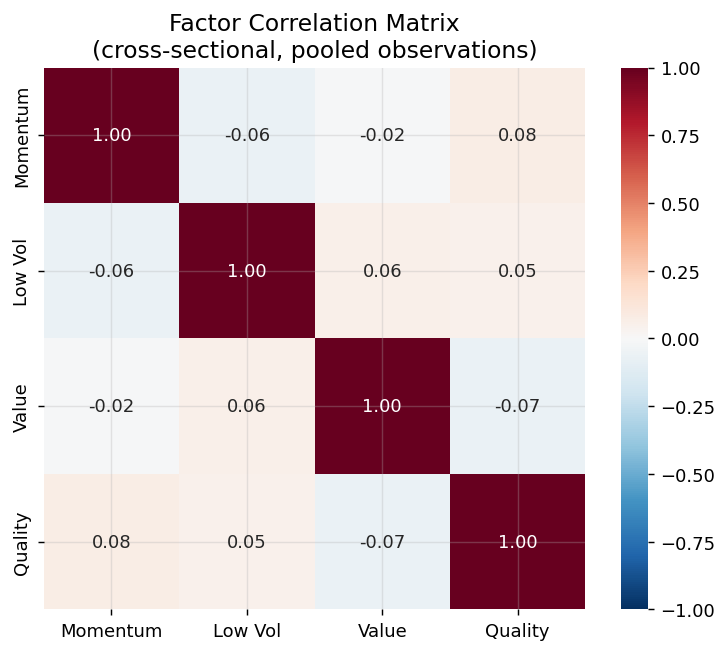

Low inter-factor correlation is desirable — diversified signal.


In [77]:
# ── Composite factor score ──
# Align all factor DataFrames to common tickers & dates
common_cols  = (factor_momentum.columns
                .intersection(factor_lowvol.columns)
                .intersection(factor_value.columns)
                .intersection(factor_quality.columns))

composite = (
    FACTOR_WEIGHTS['momentum'] * factor_momentum[common_cols] +
    FACTOR_WEIGHTS['low_vol']  * factor_lowvol[common_cols]   +
    FACTOR_WEIGHTS['value']    * factor_value[common_cols]    +
    FACTOR_WEIGHTS['quality']  * factor_quality[common_cols]
)

print(f'Composite score matrix: {composite.shape}')
print(f'Stock coverage in composite: {composite.notna().mean().mean():.1%}')

# ── Factor correlation (cross-sectional mean) ──
factor_corr_data = pd.DataFrame({
    'Momentum': factor_momentum[common_cols].stack(),
    'Low Vol':  factor_lowvol[common_cols].stack(),
    'Value':    factor_value[common_cols].stack(),
    'Quality':  factor_quality[common_cols].stack(),
}).dropna()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(factor_corr_data.corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Factor Correlation Matrix\n(cross-sectional, pooled observations)')
plt.tight_layout()
plt.savefig('factor_correlations.png', bbox_inches='tight')
plt.show()
print('Low inter-factor correlation is desirable — diversified signal.')

## 4. Portfolio Construction

Three variants are built for comparison:

- **Long-Only (primary):** Top 20% stocks globally ranked by composite score, equally weighted.
- **Sector-Neutral:** Top 20% selected within each GICS sector, giving implicit equal sector exposure. Included to test whether IS outperformance was driven by sector bets rather than stock selection.
- **Long/Short :** Dollar-neutral top/bottom 20%. The universes bottom 20% still appreciates in bull markets, making shorts consistently loss-making before costs.

Transaction costs are applied as turnover × 2 × 10 bps per rebalance, capturing round-trip slippage on changed positions only.

In [79]:
# ── Sector mapping from universe ──
# Map ticker -> sector, filtered to common_cols only
sector_map = (sp500_info.set_index('ticker')['sector']
              .reindex(common_cols)
              .dropna())

print(f'Sector map coverage: {len(sector_map)}/{len(common_cols)} tickers')
print(sector_map.value_counts().to_string())


def build_portfolio(
    composite_scores: pd.DataFrame,
    monthly_rets: pd.DataFrame,
    top_pct: float = TOP_QUINTILE,
    transaction_cost: float = TRANSACTION_COST,
) -> pd.DataFrame:
    """
    Construct monthly equal-weighted long-only portfolio from top 20% scores.
    Global ranking across all stocks.
    """
    dates = composite_scores.index
    results = []
    prev_holdings = set()

    for i, date in enumerate(dates[1:], start=1):
        signal_date = dates[i - 1]
        return_date = date

        scores = composite_scores.loc[signal_date].dropna()
        if len(scores) < 20:
            continue

        n_select = max(1, int(np.floor(len(scores) * top_pct)))
        selected = set(scores.nlargest(n_select).index)

        available_rets = monthly_rets.loc[return_date, list(selected)].dropna()
        if len(available_rets) < 5:
            continue

        gross_ret = available_rets.mean()

        if prev_holdings:
            turnover = len(selected.symmetric_difference(prev_holdings)) / (
                       len(selected.union(prev_holdings)))
        else:
            turnover = 1.0

        tc_drag = turnover * transaction_cost * 2
        net_ret = gross_ret - tc_drag

        results.append({
            'date':         return_date,
            'gross_return': gross_ret,
            'net_return':   net_ret,
            'n_holdings':   len(available_rets),
            'turnover':     turnover,
            'tc_drag':      tc_drag,
        })
        prev_holdings = selected

    return pd.DataFrame(results).set_index('date')


def build_sector_neutral_portfolio(
    composite_scores: pd.DataFrame,
    monthly_rets: pd.DataFrame,
    sector_map: pd.Series,
    top_pct: float = TOP_QUINTILE,
    transaction_cost: float = TRANSACTION_COST,
    min_sector_stocks: int = 3,
) -> pd.DataFrame:
    """
    Sector-neutral long-only portfolio.
    
    For each month, ranks stocks within each sector independently and selects
    the top `top_pct` from each sector. Portfolio is equal-weighted across
    all selected stocks, giving implicit equal sector weight.
    
    Sectors with fewer than `min_sector_stocks` stocks are skipped to avoid
    over-concentration in small sectors.
    """
    dates    = composite_scores.index
    results  = []
    prev_holdings = set()

    sectors  = sector_map.unique()

    for i, date in enumerate(dates[1:], start=1):
        signal_date = dates[i - 1]
        return_date = date

        all_scores = composite_scores.loc[signal_date].dropna()
        selected   = set()

        for sector in sectors:
            # Tickers in this sector that have a valid score
            sector_tickers = sector_map[sector_map == sector].index
            sector_scores  = all_scores.reindex(sector_tickers).dropna()

            if len(sector_scores) < min_sector_stocks:
                continue

            n_select = max(1, int(np.floor(len(sector_scores) * top_pct)))
            top_in_sector = set(sector_scores.nlargest(n_select).index)
            selected |= top_in_sector

        if len(selected) < 10:
            continue

        available_rets = monthly_rets.loc[return_date, list(selected)].dropna()
        if len(available_rets) < 5:
            continue

        gross_ret = available_rets.mean()

        if prev_holdings:
            turnover = len(selected.symmetric_difference(prev_holdings)) / (
                       len(selected.union(prev_holdings)))
        else:
            turnover = 1.0

        tc_drag = turnover * transaction_cost * 2
        net_ret = gross_ret - tc_drag

        results.append({
            'date':         return_date,
            'gross_return': gross_ret,
            'net_return':   net_ret,
            'n_holdings':   len(available_rets),
            'turnover':     turnover,
            'tc_drag':      tc_drag,
        })
        prev_holdings = selected

    return pd.DataFrame(results).set_index('date')


def build_longshort_portfolio(
    composite_scores: pd.DataFrame,
    monthly_rets: pd.DataFrame,
    top_pct: float = TOP_QUINTILE,
    bottom_pct: float = TOP_QUINTILE,
    transaction_cost: float = TRANSACTION_COST,
    borrow_cost_annual: float = 0.005,
) -> pd.DataFrame:
    """
    Dollar-neutral long/short portfolio.
    """
    borrow_cost_monthly = (1 + borrow_cost_annual) ** (1/12) - 1
    dates  = composite_scores.index
    results = []
    prev_long  = set()
    prev_short = set()

    for i, date in enumerate(dates[1:], start=1):
        signal_date = dates[i - 1]
        return_date = date

        scores = composite_scores.loc[signal_date].dropna()
        if len(scores) < 40:
            continue

        n_select       = max(1, int(np.floor(len(scores) * top_pct)))
        long_selected  = set(scores.nlargest(n_select).index)
        short_selected = set(scores.nsmallest(n_select).index) - long_selected

        long_rets  = monthly_rets.loc[return_date, list(long_selected)].dropna()
        short_rets = monthly_rets.loc[return_date, list(short_selected)].dropna()

        if len(long_rets) < 5 or len(short_rets) < 5:
            continue

        gross_ret = long_rets.mean() - short_rets.mean()

        if prev_long:
            long_turnover  = len(long_selected.symmetric_difference(prev_long)) / (
                             len(long_selected.union(prev_long)))
            short_turnover = len(short_selected.symmetric_difference(prev_short)) / (
                             len(short_selected.union(prev_short)))
        else:
            long_turnover = short_turnover = 1.0

        tc_drag = (long_turnover + short_turnover) * transaction_cost * 2
        net_ret = gross_ret - tc_drag - borrow_cost_monthly

        results.append({
            'date':          return_date,
            'gross_return':  gross_ret,
            'net_return':    net_ret,
            'long_return':   long_rets.mean(),
            'short_return':  short_rets.mean(),
            'n_long':        len(long_rets),
            'n_short':       len(short_rets),
            'long_turnover': long_turnover,
            'short_turnover':short_turnover,
            'tc_drag':       tc_drag,
            'borrow_cost':   borrow_cost_monthly,
        })
        prev_long  = long_selected
        prev_short = short_selected

    return pd.DataFrame(results).set_index('date')


# ── Build all three portfolios ──
portfolio    = build_portfolio(composite, monthly_returns[common_cols])
portfolio_sn = build_sector_neutral_portfolio(
    composite, monthly_returns[common_cols], sector_map)
portfolio_ls = build_longshort_portfolio(composite, monthly_returns[common_cols])

print('\nOriginal Long-Only:')
print(f'  Observations : {len(portfolio)}')
print(f'  Avg holdings : {portfolio["n_holdings"].mean():.0f} stocks')
print(f'  Avg turnover : {portfolio["turnover"].mean():.1%}/month')
print(f'  Avg TC drag  : {portfolio["tc_drag"].mean()*10000:.2f} bps/month')

print('\nSector-Neutral Long-Only:')
print(f'  Observations : {len(portfolio_sn)}')
print(f'  Avg holdings : {portfolio_sn["n_holdings"].mean():.0f} stocks')
print(f'  Avg turnover : {portfolio_sn["turnover"].mean():.1%}/month')
print(f'  Avg TC drag  : {portfolio_sn["tc_drag"].mean()*10000:.2f} bps/month')

print('\nLong/Short:')
print(f'  Observations : {len(portfolio_ls)}')
print(f'  Avg TC drag  : {portfolio_ls["tc_drag"].mean()*10000:.2f} bps/month')

Sector map coverage: 190/190 tickers
sector
Financials                28
Information Technology    26
Industrials               24
Health Care               23
Consumer Discretionary    19
Consumer Staples          15
Communication Services    14
Energy                    12
Real Estate               10
Materials                 10
Utilities                  9

Original Long-Only:
  Observations : 190
  Avg holdings : 38 stocks
  Avg turnover : 31.7%/month
  Avg TC drag  : 6.35 bps/month

Sector-Neutral Long-Only:
  Observations : 190
  Avg holdings : 33 stocks
  Avg turnover : 35.7%/month
  Avg TC drag  : 7.14 bps/month

Long/Short:
  Observations : 190
  Avg TC drag  : 12.31 bps/month


## 5. Benchmark — SPY (S&P 500 ETF)

In [80]:
spy_raw     = yf.download('SPY', start=START_DATE, end=END_DATE,
                           auto_adjust=True, progress=False)
spy_monthly = spy_raw['Close'].resample('ME').last().pct_change().dropna().squeeze()
spy_monthly.name = 'SPY'

# Align all three to common dates
common_dates = (portfolio.index
                .intersection(portfolio_ls.index)
                .intersection(spy_monthly.index))

portfolio     = portfolio.loc[common_dates]
portfolio_ls  = portfolio_ls.loc[common_dates]
spy_aligned   = spy_monthly.loc[common_dates]

print(f'Aligned dates: {len(common_dates)} months')
print(f'Date range:    {common_dates[0].date()} → {common_dates[-1].date()}')

Aligned dates: 190 months
Date range:    2010-03-31 → 2026-04-30


## 6. Performance Analytics — Helper Functions

In [81]:
def performance_metrics(returns: pd.Series, rf_annual: float = RISK_FREE_RATE,
                         label: str = 'Strategy') -> dict:
    """Compute comprehensive performance metrics from a monthly return series."""
    rf_monthly     = (1 + rf_annual) ** (1/12) - 1
    excess_returns = returns - rf_monthly

    wealth         = (1 + returns).cumprod()
    n_months       = len(returns)
    n_years        = n_months / 12

    total_return   = wealth.iloc[-1] - 1
    cagr           = wealth.iloc[-1] ** (1 / n_years) - 1
    annual_vol     = returns.std() * np.sqrt(12)
    sharpe         = (excess_returns.mean() / returns.std()) * np.sqrt(12)

    rolling_max    = wealth.cummax()
    drawdown       = (wealth - rolling_max) / rolling_max
    max_dd         = float(drawdown.min().squeeze())
    calmar         = cagr / abs(max_dd) if max_dd != 0 else np.nan

    downside       = returns[returns < rf_monthly]
    downside_std   = float(downside.std() * np.sqrt(12)) if len(downside) > 0 else np.nan
    sortino        = (cagr - rf_annual) / downside_std if downside_std else np.nan

    win_rate       = (returns > 0).mean()
    skew           = returns.skew()
    kurt           = returns.kurtosis()

    return {
        'Label':            label,
        'Total Return':     f'{total_return:.1%}',
        'CAGR':             f'{cagr:.2%}',
        'Annual Vol':       f'{annual_vol:.2%}',
        'Sharpe Ratio':     f'{sharpe:.3f}',
        'Sortino Ratio':    f'{sortino:.3f}',
        'Max Drawdown':     f'{max_dd:.2%}',
        'Calmar Ratio':     f'{calmar:.3f}',
        'Win Rate':         f'{win_rate:.1%}',
        'Skewness':         f'{skew:.3f}',
        'Excess Kurtosis':  f'{kurt:.3f}',
        '_cagr':            cagr,
        '_vol':             annual_vol,
        '_sharpe':          sharpe,
        '_max_dd':          max_dd,
        '_wealth':          wealth,
        '_drawdown':        drawdown,
    }


def plot_three_way(lo_returns: pd.Series, ls_returns: pd.Series,
                   bench_returns: pd.Series, title: str) -> None:
    """
    Plot cumulative returns and drawdowns for three strategies:
    long-only, long/short, and SPY benchmark.
    
    Note: L/S returns are dollar-neutral so absolute level is not
    directly comparable to long-only — the chart shows relative
    risk-adjusted trajectory.
    """
    lo_wealth    = (1 + lo_returns).cumprod()
    ls_wealth    = (1 + ls_returns).cumprod()
    bench_wealth = (1 + bench_returns).cumprod()

    lo_dd    = (lo_wealth    - lo_wealth.cummax())    / lo_wealth.cummax()
    ls_dd    = (ls_wealth    - ls_wealth.cummax())    / ls_wealth.cummax()
    bench_dd = (bench_wealth - bench_wealth.cummax()) / bench_wealth.cummax()

    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(4, 1, height_ratios=[3, 1, 1, 1], hspace=0.08)

    # ── Cumulative returns ──
    ax0 = fig.add_subplot(gs[0])
    ax0.plot(lo_wealth.index,    lo_wealth.values,    color=COLORS['strategy'],
             lw=2, label='Long-Only (net of TC)')
    ax0.plot(ls_wealth.index,    ls_wealth.values,    color=COLORS['positive'],
             lw=2, label='Long/Short (net of TC + borrow)', ls='--')
    ax0.plot(bench_wealth.index, bench_wealth.values, color=COLORS['benchmark'],
             lw=2, label='SPY Benchmark', alpha=0.8)
    ax0.set_ylabel('Portfolio Value ($1 invested)')
    ax0.set_title(title, fontweight='bold', pad=12)
    ax0.legend(frameon=False)
    ax0.set_yscale('log')
    ax0.set_xticklabels([])

    # ── Long-only drawdown ──
    ax1 = fig.add_subplot(gs[1])
    ax1.fill_between(lo_dd.index, lo_dd.values, 0,
                     color=COLORS['strategy'], alpha=0.4, label='Long-Only DD')
    ax1.set_ylabel('DD')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax1.legend(frameon=False, fontsize=9)
    ax1.set_xticklabels([])

    # ── Long/short drawdown ──
    ax2 = fig.add_subplot(gs[2])
    ax2.fill_between(ls_dd.index, ls_dd.values, 0,
                     color=COLORS['positive'], alpha=0.4, label='Long/Short DD')
    ax2.set_ylabel('DD')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax2.legend(frameon=False, fontsize=9)
    ax2.set_xticklabels([])

    # ── SPY drawdown ──
    ax3 = fig.add_subplot(gs[3])
    ax3.fill_between(bench_dd.index, bench_dd.values, 0,
                     color=COLORS['benchmark'], alpha=0.4, label='SPY DD')
    ax3.set_ylabel('DD')
    ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax3.legend(frameon=False, fontsize=9)

    fname = title.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

def plot_three_way_sn(lo_returns: pd.Series, sn_returns: pd.Series,
                      bench_returns: pd.Series, title: str) -> None:
    """
    Plot cumulative returns and drawdowns for:
    original long-only, sector-neutral long-only, and SPY.
    """
    lo_wealth    = (1 + lo_returns).cumprod()
    sn_wealth    = (1 + sn_returns).cumprod()
    bench_wealth = (1 + bench_returns).cumprod()

    lo_dd    = (lo_wealth    - lo_wealth.cummax())    / lo_wealth.cummax()
    sn_dd    = (sn_wealth    - sn_wealth.cummax())    / sn_wealth.cummax()
    bench_dd = (bench_wealth - bench_wealth.cummax()) / bench_wealth.cummax()

    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(4, 1, height_ratios=[3, 1, 1, 1], hspace=0.08)

    ax0 = fig.add_subplot(gs[0])
    ax0.plot(lo_wealth.index,    lo_wealth.values,    color=COLORS['strategy'],
             lw=2, label='Long-Only (original)')
    ax0.plot(sn_wealth.index,    sn_wealth.values,    color=COLORS['positive'],
             lw=2, label='Long-Only (sector-neutral)', ls='--')
    ax0.plot(bench_wealth.index, bench_wealth.values, color=COLORS['benchmark'],
             lw=2, label='SPY Benchmark', alpha=0.8)
    ax0.set_ylabel('Portfolio Value ($1 invested)')
    ax0.set_title(title, fontweight='bold', pad=12)
    ax0.legend(frameon=False)
    ax0.set_yscale('log')
    ax0.set_xticklabels([])

    ax1 = fig.add_subplot(gs[1])
    ax1.fill_between(lo_dd.index, lo_dd.values, 0,
                     color=COLORS['strategy'], alpha=0.4, label='Long-Only DD')
    ax1.set_ylabel('DD')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax1.legend(frameon=False, fontsize=9)
    ax1.set_xticklabels([])

    ax2 = fig.add_subplot(gs[2])
    ax2.fill_between(sn_dd.index, sn_dd.values, 0,
                     color=COLORS['positive'], alpha=0.4, label='Sector-Neutral DD')
    ax2.set_ylabel('DD')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax2.legend(frameon=False, fontsize=9)
    ax2.set_xticklabels([])

    ax3 = fig.add_subplot(gs[3])
    ax3.fill_between(bench_dd.index, bench_dd.values, 0,
                     color=COLORS['benchmark'], alpha=0.4, label='SPY DD')
    ax3.set_ylabel('DD')
    ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax3.legend(frameon=False, fontsize=9)

    fname = title.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

# Keep old function for any cells that still use it
def plot_cumulative_returns(strat_returns: pd.Series, bench_returns: pd.Series,
                             title: str) -> None:
    """Plot cumulative returns with drawdown panel (two-strategy version)."""
    strat_wealth = (1 + strat_returns).cumprod()
    bench_wealth = (1 + bench_returns).cumprod()

    strat_dd = (strat_wealth - strat_wealth.cummax()) / strat_wealth.cummax()
    bench_dd = (bench_wealth - bench_wealth.cummax()) / bench_wealth.cummax()

    fig = plt.figure(figsize=(14, 8))
    gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.1)

    ax0 = fig.add_subplot(gs[0])
    ax0.plot(strat_wealth.index, strat_wealth.values, color=COLORS['strategy'],
             lw=2, label='Strategy (net of TC)')
    ax0.plot(bench_wealth.index, bench_wealth.values, color=COLORS['benchmark'],
             lw=2, label='SPY Benchmark', alpha=0.8)
    ax0.set_ylabel('Portfolio Value ($1 invested)')
    ax0.set_title(title, fontweight='bold', pad=12)
    ax0.legend(frameon=False)
    ax0.set_yscale('log')
    ax0.set_xticklabels([])

    ax1 = fig.add_subplot(gs[1])
    ax1.fill_between(strat_dd.index, strat_dd.values, 0,
                     color=COLORS['strategy'], alpha=0.4, label='Strategy DD')
    ax1.set_ylabel('Drawdown')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax1.legend(frameon=False, fontsize=9)
    ax1.set_xticklabels([])

    ax2 = fig.add_subplot(gs[2])
    ax2.fill_between(bench_dd.index, bench_dd.values, 0,
                     color=COLORS['benchmark'], alpha=0.4, label='SPY DD')
    ax2.set_ylabel('Drawdown')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax2.legend(frameon=False, fontsize=9)

    fname = title.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()


## 7. In-Sample Performance (2010–2018)

Parameters were calibrated over this period and then frozen. Any IS metrics should be taken with a grain of salt. The point of this section is to establish a baseline for the IS -> OOS degradation check in Section 8.

════════════════════════════════════════════════════════════════════
IN-SAMPLE PERFORMANCE  (2010–2018)
════════════════════════════════════════════════════════════════════
         Metric Long-Only Sector-Neutral     SPY
   Total Return    321.3%         376.5%  170.5%
           CAGR    17.68%         19.33%  11.93%
     Annual Vol    13.19%         12.79%  12.35%
   Sharpe Ratio     1.010          1.148   0.659
  Sortino Ratio     1.520          1.644   0.905
   Max Drawdown   -16.68%        -16.93% -16.22%
   Calmar Ratio     1.060          1.142   0.735
       Win Rate     66.0%          70.8%   69.8%
       Skewness    -0.540         -0.611  -0.319
Excess Kurtosis     0.497          0.712   0.646

  Long-Only:
    Beta  : 0.983
    Alpha : 5.52% (annualised)  p=0.0000

  Sector-Neutral:
    Beta  : 0.955
    Alpha : 7.32% (annualised)  p=0.0000


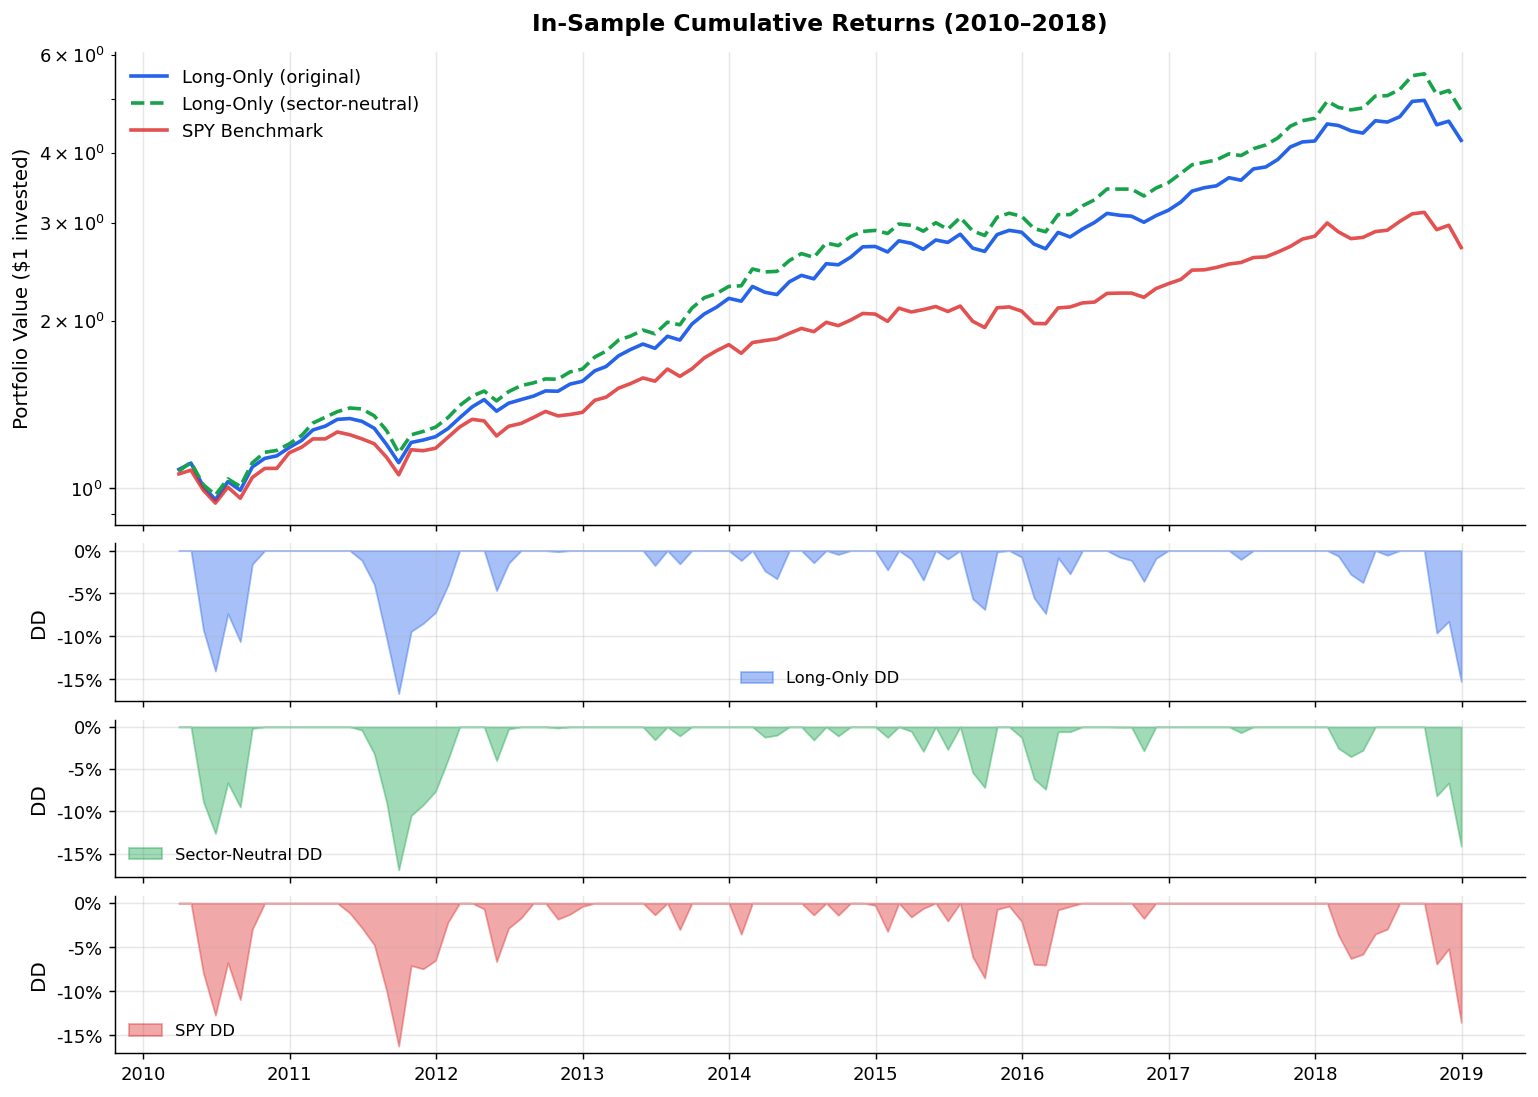

In [82]:
# ── Slice in-sample period ──
is_mask    = (portfolio.index >= '2010-01-01') & (portfolio.index <= IS_END_DATE)
is_strat   = portfolio.loc[is_mask, 'net_return']
is_sn      = portfolio_sn.loc[is_mask, 'net_return']
is_bench   = spy_aligned.loc[is_mask]

is_metrics_lo    = performance_metrics(is_strat, label='Long-Only (IS)')
is_metrics_sn    = performance_metrics(is_sn,    label='Sector-Neutral (IS)')
is_metrics_bench = performance_metrics(is_bench, label='SPY (IS)')

metric_keys = ['Total Return', 'CAGR', 'Annual Vol', 'Sharpe Ratio',
               'Sortino Ratio', 'Max Drawdown', 'Calmar Ratio', 'Win Rate',
               'Skewness', 'Excess Kurtosis']

is_table = pd.DataFrame({
    'Metric':          metric_keys,
    'Long-Only':       [is_metrics_lo[k] for k in metric_keys],
    'Sector-Neutral':  [is_metrics_sn[k] for k in metric_keys],
    'SPY':             [is_metrics_bench[k] for k in metric_keys],
})
print('═' * 68)
print('IN-SAMPLE PERFORMANCE  (2010–2018)')
print('═' * 68)
print(is_table.to_string(index=False))

for label, rets in [('Long-Only', is_strat), ('Sector-Neutral', is_sn)]:
    slope, intercept, r, p, se = stats.linregress(is_bench.values, rets.values)
    annual_alpha = (1 + intercept) ** 12 - 1
    print(f'\n  {label}:')
    print(f'    Beta  : {slope:.3f}')
    print(f'    Alpha : {annual_alpha:.2%} (annualised)  p={p:.4f}')

plot_three_way_sn(is_strat, is_sn, is_bench,
                  'In-Sample Cumulative Returns (2010–2018)')

## 8. Out-of-Sample Performance (2019–Present)

The OOS period is the only honest test. Parameters were fixed at end of 2018 and not revisited. The IS→OOS degradation table at the bottom of this cell is the key diagnostic: a Sharpe that roughly halves is expected and acceptable; a Sharpe that collapses to near zero would suggest the IS result was largely overfitted.

════════════════════════════════════════════════════════════════════
OUT-OF-SAMPLE PERFORMANCE  (2019–Present)
════════════════════════════════════════════════════════════════════
         Metric Long-Only Sector-Neutral     SPY
   Total Return    230.0%         224.6%  248.2%
           CAGR    18.60%         18.32%  19.51%
     Annual Vol    16.19%         16.26%  16.56%
   Sharpe Ratio     0.897          0.880   0.929
  Sortino Ratio     1.455          1.476   1.439
   Max Drawdown   -17.55%        -18.36% -19.45%
   Calmar Ratio     1.060          0.998   1.003
       Win Rate     66.7%          67.9%   67.9%
       Skewness    -0.103         -0.243  -0.407
Excess Kurtosis    -0.067          0.018   0.296

  Long-Only:
    Beta  : 0.875
    Alpha : 1.57% (annualised)  p=0.0000

  Sector-Neutral:
    Beta  : 0.891
    Alpha : 1.04% (annualised)  p=0.0000

── IS -> OOS Degradation Check ──

  Long-Only:
    Sharpe IS: 1.010   OOS: 0.897
    CAGR   IS: 17.68%   OOS: 18.60%
    MaxDD  

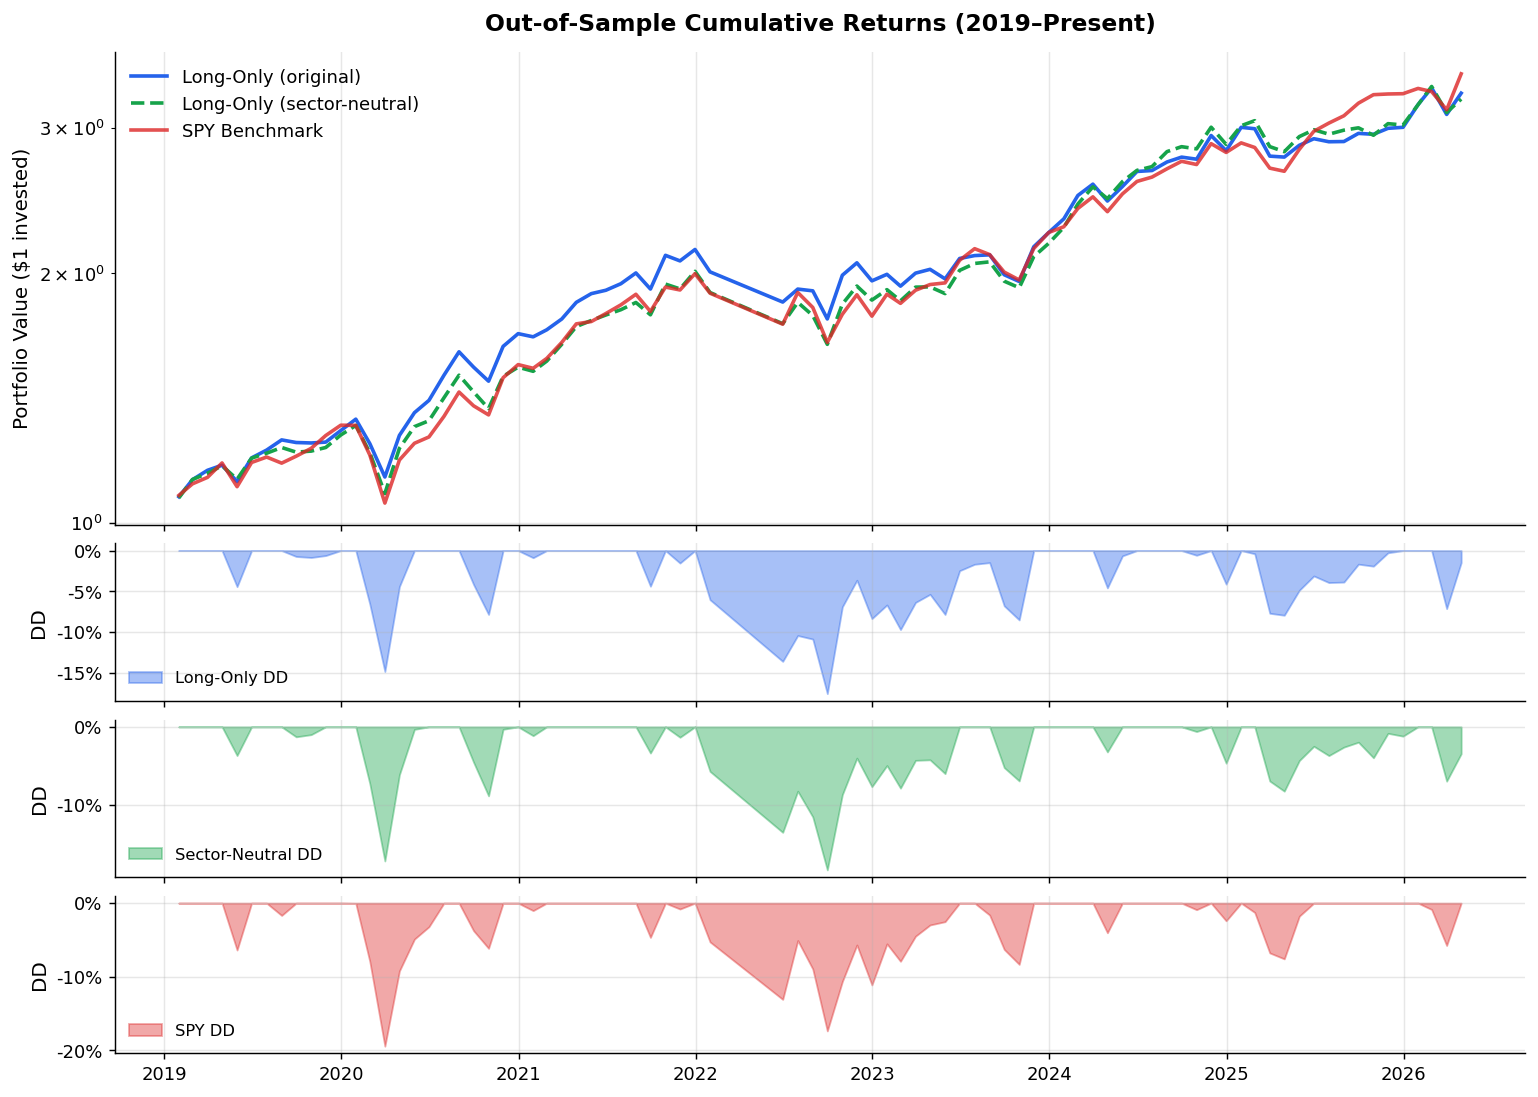

In [83]:
# ── Slice OOS period ──
oos_mask  = portfolio.index >= OOS_START_DATE
oos_strat = portfolio.loc[oos_mask, 'net_return']
oos_sn    = portfolio_sn.loc[oos_mask, 'net_return']
oos_bench = spy_aligned.loc[oos_mask]

oos_metrics_lo    = performance_metrics(oos_strat, label='Long-Only (OOS)')
oos_metrics_sn    = performance_metrics(oos_sn,    label='Sector-Neutral (OOS)')
oos_metrics_bench = performance_metrics(oos_bench, label='SPY (OOS)')

oos_table = pd.DataFrame({
    'Metric':          metric_keys,
    'Long-Only':       [oos_metrics_lo[k] for k in metric_keys],
    'Sector-Neutral':  [oos_metrics_sn[k] for k in metric_keys],
    'SPY':             [oos_metrics_bench[k] for k in metric_keys],
})
print('═' * 68)
print('OUT-OF-SAMPLE PERFORMANCE  (2019–Present)')
print('═' * 68)
print(oos_table.to_string(index=False))

for label, rets in [('Long-Only', oos_strat), ('Sector-Neutral', oos_sn)]:
    slope, intercept, r, p, se = stats.linregress(oos_bench.values, rets.values)
    annual_alpha = (1 + intercept) ** 12 - 1
    print(f'\n  {label}:')
    print(f'    Beta  : {slope:.3f}')
    print(f'    Alpha : {annual_alpha:.2%} (annualised)  p={p:.4f}')

print('\n── IS -> OOS Degradation Check ──')
for label, is_m, oos_m in [
    ('Long-Only',      is_metrics_lo, oos_metrics_lo),
    ('Sector-Neutral', is_metrics_sn, oos_metrics_sn),
]:
    print(f'\n  {label}:')
    print(f'    Sharpe IS: {is_m["_sharpe"]:.3f}   OOS: {oos_m["_sharpe"]:.3f}')
    print(f'    CAGR   IS: {is_m["_cagr"]:.2%}   OOS: {oos_m["_cagr"]:.2%}')
    print(f'    MaxDD  IS: {is_m["_max_dd"]:.2%}   OOS: {oos_m["_max_dd"]:.2%}')

plot_three_way_sn(oos_strat, oos_sn, oos_bench,
                  'Out-of-Sample Cumulative Returns (2019–Present)')

In [85]:
# ── Long/Short: documented failure analysis ──
# This section is kept intentionally to help understand why the strategy fails

full_mask = portfolio_ls.index >= '2010-01-01'
ls_full   = portfolio_ls.loc[full_mask]

long_avg   = ls_full['long_return'].mean() * 100
short_avg  = ls_full['short_return'].mean() * 100
spread     = (ls_full['long_return'] - ls_full['short_return']).mean() * 100
cost_drag  = (ls_full['tc_drag'] + ls_full['borrow_cost']).mean() * 100
bottom_cagr = (1 + ls_full['short_return'].mean()) ** 12 - 1

print('Long/Short Decomposition (full period):')
print(f'  Long leg avg return   : {long_avg:.3f}%/month')
print(f'  Short leg avg return  : {short_avg:.3f}%/month')
print(f'  Gross spread          : {spread:.3f}%/month')
print(f'  TC + borrow drag      : {cost_drag:.3f}%/month')
print(f'  Short leg CAGR        : {bottom_cagr:.2%}  (positive — the core problem)')

print("""
Diagnosis
─────────
The strategy fails for three compounding reasons:

  1. Universe quality floor. The S&P 500 bottom 20% contains the
     weakest large-caps, not genuinely weak companies. These stocks still
     drift upward in bull markets, making the short leg a persistent drag.

  2. Narrow factor spread. With 200 stocks of similar quality, the
     composite score gap between top and bottom 20% is small. The
     short leg barely underperforms the long before costs.

  3. Cost asymmetry. Transaction costs and borrow drag double on two legs,
     and the gross spread is insufficient to absorb them.

Conclusion: long/short factor strategies need a broader, more heterogeneous
universe (Russell 3000 or all-cap) where the bottom 20% contains
genuinely deteriorating businesses. On the S&P 500, long-only is the only
implementation that survives cost.""")

Long/Short Decomposition (full period):
  Long leg avg return   : 1.546%/month
  Short leg avg return  : 1.755%/month
  Gross spread          : -0.209%/month
  TC + borrow drag      : 0.165%/month
  Short leg CAGR        : 23.21%  (positive — the core problem)

Diagnosis
─────────
The strategy fails for three compounding reasons:

  1. Universe quality floor. The S&P 500 bottom 20% contains the
     weakest large-caps, not genuinely weak companies. These stocks still
     drift upward in bull markets, making the short leg a persistent drag.

  2. Narrow factor spread. With 200 stocks of similar quality, the
     composite score gap between top and bottom 20% is small. The
     short leg barely underperforms the long before costs.

  3. Cost asymmetry. Transaction costs and borrow drag double on two legs,
     and the gross spread is insufficient to absorb them.

Conclusion: long/short factor strategies need a broader, more heterogeneous
universe (Russell 3000 or all-cap) where the bott

## 9. Walk-Forward Analysis

Rolling 36-month windows, stepped monthly. A strategy with genuine alpha should show persistently positive Sharpe across most windows, not just a favourable full-period Sharpe that masks a handful of bad stretches. The negative periods, and their macro context, are as informative as the positive ones.

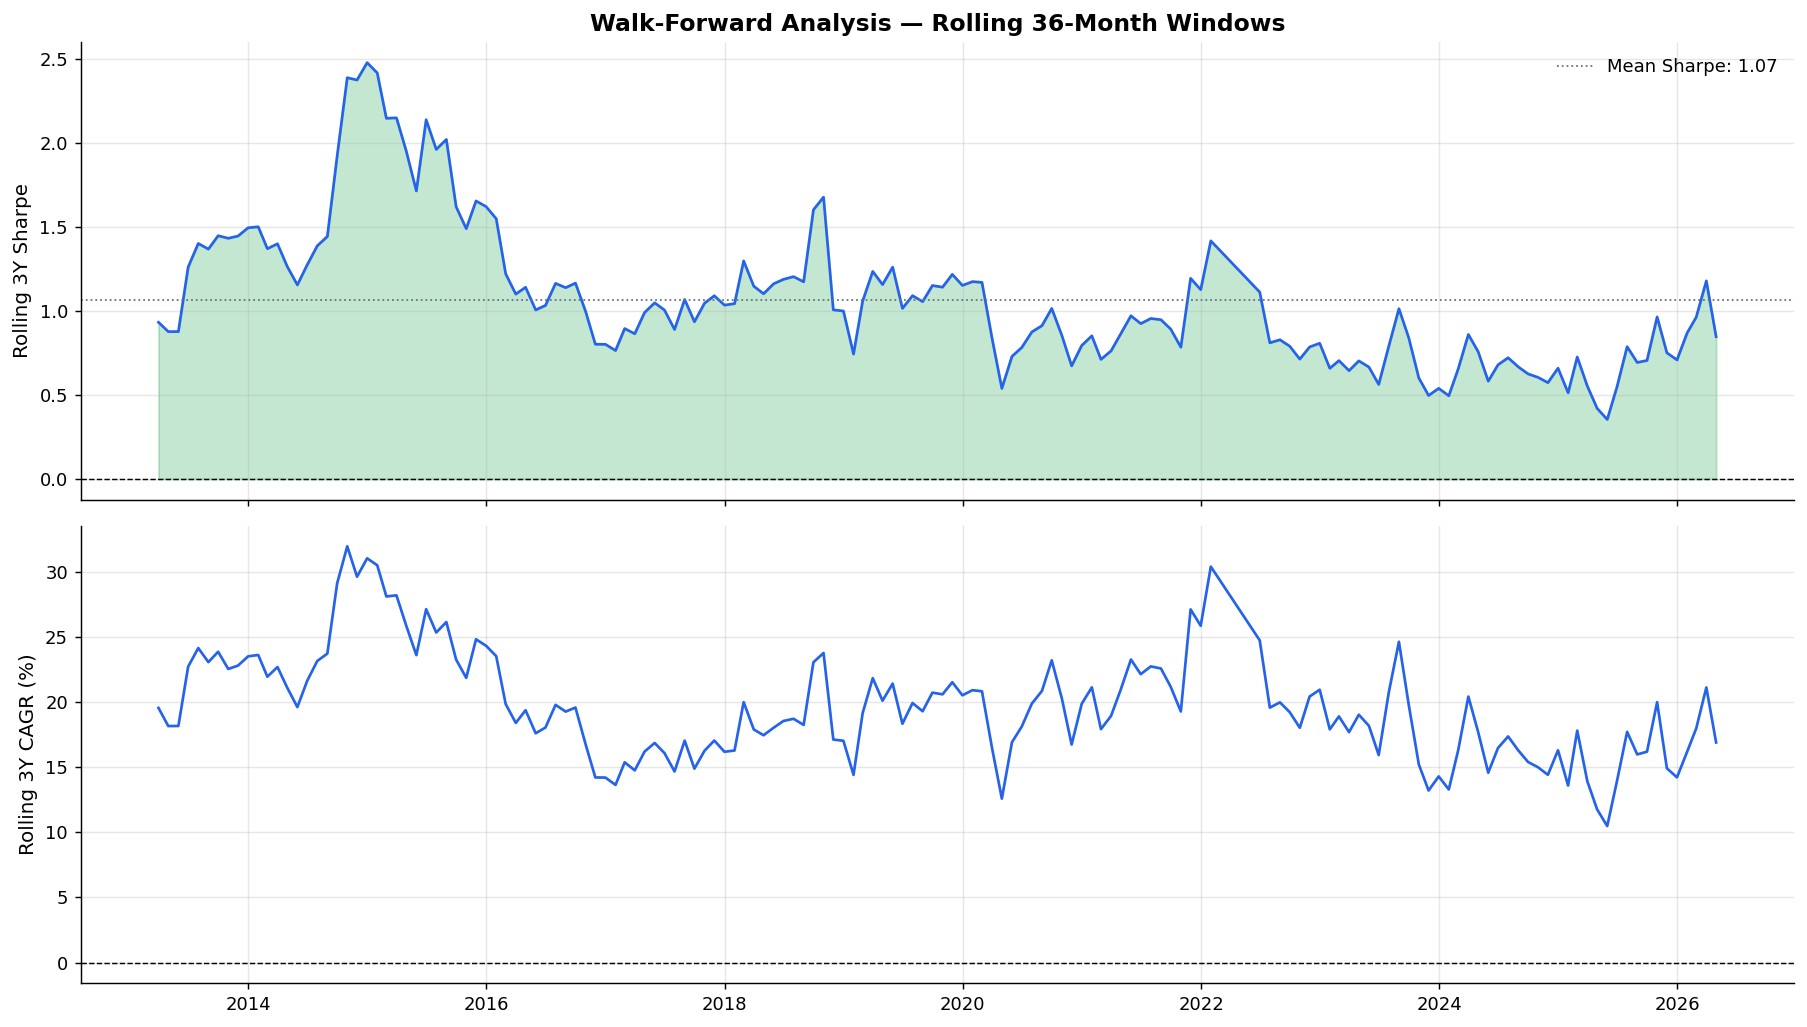

Windows with positive Sharpe : 100.0%
Mean rolling Sharpe          : 1.066
Std dev rolling Sharpe       : 0.424
Min rolling Sharpe           : 0.353  (worst 3Y window)


In [86]:
WINDOW_MONTHS = 36   # 3-year rolling window

all_returns  = portfolio['net_return']
roll_sharpes = []
roll_cagrs   = []
roll_dates   = []

for end_idx in range(WINDOW_MONTHS, len(all_returns)):
    window_rets = all_returns.iloc[end_idx - WINDOW_MONTHS : end_idx]
    rf_monthly  = (1 + RISK_FREE_RATE) ** (1/12) - 1
    sharpe = (window_rets.mean() - rf_monthly) / window_rets.std() * np.sqrt(12)
    cagr   = (1 + window_rets.mean()) ** 12 - 1
    roll_sharpes.append(sharpe)
    roll_cagrs.append(cagr)
    roll_dates.append(all_returns.index[end_idx])

roll_df = pd.DataFrame({'sharpe': roll_sharpes, 'cagr': roll_cagrs}, index=roll_dates)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(roll_df.index, roll_df['sharpe'], color=COLORS['strategy'], lw=1.5)
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].axhline(roll_df['sharpe'].mean(), color=COLORS['neutral'], lw=1, ls=':',
                label=f'Mean Sharpe: {roll_df["sharpe"].mean():.2f}')
axes[0].fill_between(roll_df.index, roll_df['sharpe'], 0,
                      where=roll_df['sharpe'] > 0, alpha=0.25, color=COLORS['positive'])
axes[0].fill_between(roll_df.index, roll_df['sharpe'], 0,
                      where=roll_df['sharpe'] < 0, alpha=0.25, color=COLORS['negative'])
axes[0].set_ylabel('Rolling 3Y Sharpe')
axes[0].set_title('Walk-Forward Analysis — Rolling 36-Month Windows', fontweight='bold')
axes[0].legend(frameon=False)

axes[1].plot(roll_df.index, roll_df['cagr'] * 100, color=COLORS['strategy'], lw=1.5)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_ylabel('Rolling 3Y CAGR (%)')

plt.tight_layout()
plt.savefig('walk_forward_analysis.png', bbox_inches='tight')
plt.show()

pct_pos = (roll_df['sharpe'] > 0).mean()
print(f'Windows with positive Sharpe : {pct_pos:.1%}')
print(f'Mean rolling Sharpe          : {roll_df["sharpe"].mean():.3f}')
print(f'Std dev rolling Sharpe       : {roll_df["sharpe"].std():.3f}')
print(f'Min rolling Sharpe           : {roll_df["sharpe"].min():.3f}  (worst 3Y window)')

## 10. Monte Carlo Bootstrap Simulation

Block bootstrap (block size = 3 months) on the OOS return series to preserve autocorrelation structure. 5,000 simulations produce the distribution of CAGR, Sharpe, and max drawdown outcomes, showing how lucky or unlucky the realised path was relative to the full range of possible outcomes implied by the same return process.

Running 5,000 block-bootstrap simulations on OOS period...


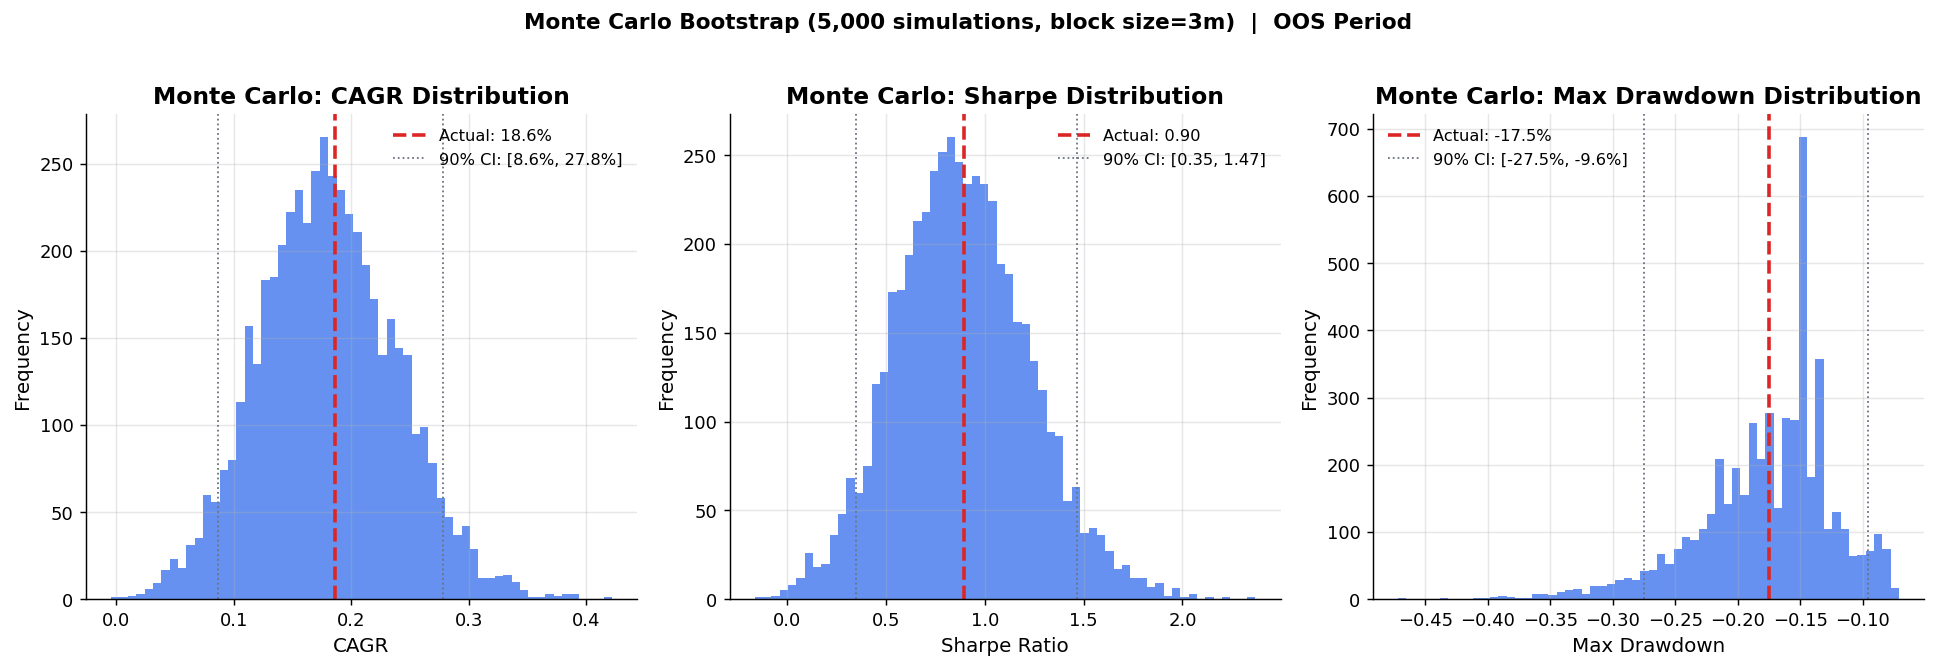


Monte Carlo OOS Summary:
  CAGR    — Median: 17.81%  5th pct: 8.64%  95th pct: 27.82%
  Sharpe  — Median: 0.876  5th pct: 0.351  95th pct: 1.467
  MaxDD   — Median: -16.57%  5th pct: -27.50%  95th pct: -9.61%

  Prob(Sharpe > 0.5) : 88.3%
  Prob(Positive CAGR): 100.0%


In [88]:
np.random.seed(RANDOM_SEED)

def bootstrap_metrics(returns: pd.Series, n_sims: int = N_MONTE_CARLO) -> pd.DataFrame:
    """Block bootstrap (block_size=3 months) to preserve autocorrelation structure."""
    block_size  = 3
    n           = len(returns)
    ret_arr     = returns.values
    results     = []

    for _ in range(n_sims):
        # Block bootstrap
        sim_rets = []
        while len(sim_rets) < n:
            start = np.random.randint(0, n - block_size)
            sim_rets.extend(ret_arr[start : start + block_size])
        sim_rets = np.array(sim_rets[:n])

        wealth     = np.cumprod(1 + sim_rets)
        cagr       = wealth[-1] ** (12 / n) - 1
        vol        = sim_rets.std() * np.sqrt(12)
        rf_monthly = (1 + RISK_FREE_RATE) ** (1/12) - 1
        sharpe     = (sim_rets.mean() - rf_monthly) / sim_rets.std() * np.sqrt(12)

        rolling_max = np.maximum.accumulate(wealth)
        max_dd      = ((wealth - rolling_max) / rolling_max).min()

        results.append({'cagr': cagr, 'sharpe': sharpe, 'max_dd': max_dd, 'vol': vol})

    return pd.DataFrame(results)


print(f'Running {N_MONTE_CARLO:,} block-bootstrap simulations on OOS period...')
mc_oos = bootstrap_metrics(oos_strat)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, label, actual_val, fmt in zip(
    axes,
    ['cagr', 'sharpe', 'max_dd'],
    ['CAGR', 'Sharpe Ratio', 'Max Drawdown'],
    [oos_metrics_lo['_cagr'], oos_metrics_lo['_sharpe'], oos_metrics_lo['_max_dd']],
    ['{:.1%}', '{:.2f}', '{:.1%}']
):
    ax.hist(mc_oos[col], bins=60, color=COLORS['strategy'], alpha=0.7, edgecolor='none')
    ax.axvline(actual_val, color=COLORS['benchmark'], lw=2, ls='--',
               label=f'Actual: {fmt.format(actual_val)}')
    p5  = mc_oos[col].quantile(0.05)
    p95 = mc_oos[col].quantile(0.95)
    ax.axvline(p5,  color=COLORS['neutral'], lw=1, ls=':')
    ax.axvline(p95, color=COLORS['neutral'], lw=1, ls=':',
               label=f'90% CI: [{fmt.format(p5)}, {fmt.format(p95)}]')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.legend(frameon=False, fontsize=9)

axes[0].set_title('Monte Carlo: CAGR Distribution', fontweight='bold')
axes[1].set_title('Monte Carlo: Sharpe Distribution', fontweight='bold')
axes[2].set_title('Monte Carlo: Max Drawdown Distribution', fontweight='bold')

plt.suptitle(f'Monte Carlo Bootstrap ({N_MONTE_CARLO:,} simulations, block size=3m)  |  OOS Period',
             y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('monte_carlo_oos.png', bbox_inches='tight')
plt.show()

print(f"\nMonte Carlo OOS Summary:")
print(f"  CAGR    — Median: {mc_oos['cagr'].median():.2%}  5th pct: {mc_oos['cagr'].quantile(0.05):.2%}  95th pct: {mc_oos['cagr'].quantile(0.95):.2%}")
print(f"  Sharpe  — Median: {mc_oos['sharpe'].median():.3f}  5th pct: {mc_oos['sharpe'].quantile(0.05):.3f}  95th pct: {mc_oos['sharpe'].quantile(0.95):.3f}")
print(f"  MaxDD   — Median: {mc_oos['max_dd'].median():.2%}  5th pct: {mc_oos['max_dd'].quantile(0.05):.2%}  95th pct: {mc_oos['max_dd'].quantile(0.95):.2%}")
print(f"\n  Prob(Sharpe > 0.5) : {(mc_oos['sharpe'] > 0.5).mean():.1%}")
print(f"  Prob(Positive CAGR): {(mc_oos['cagr'] > 0).mean():.1%}")

## 11. Factor Attribution

Single-factor portfolios isolate each factor's independent contribution: build a top 20% portfolio using only that factor's signal, net of the same transaction costs. This answers whether the composite's performance is genuinely diversified across factors or concentrated in one or two.

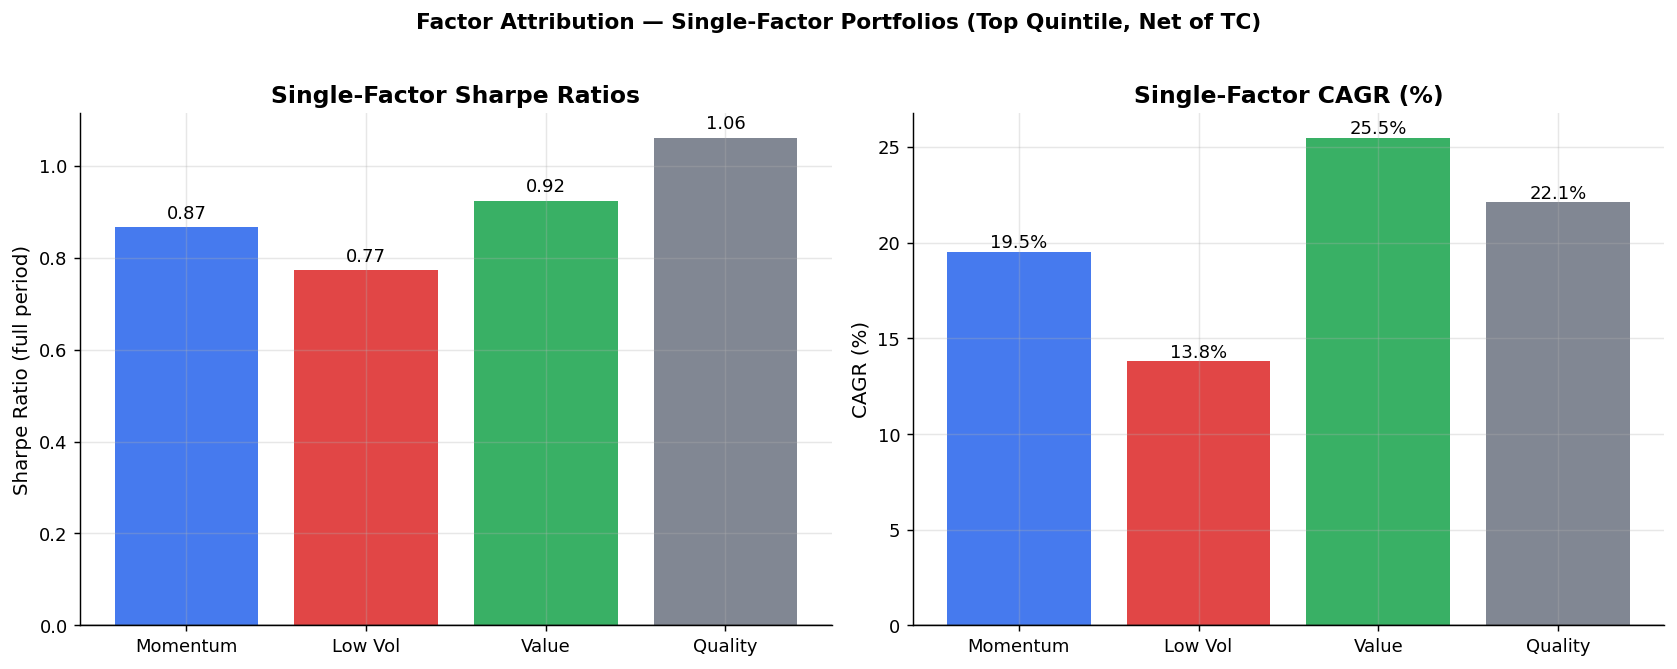


Factor portfolio return correlations (monthly):
          Momentum  Low Vol  Value  Quality
Momentum     1.000    0.766  0.773    0.871
Low Vol      0.766    1.000  0.696    0.820
Value        0.773    0.696  1.000    0.833
Quality      0.871    0.820  0.833    1.000


In [89]:
factor_frames = {
    'Momentum': factor_momentum[common_cols],
    'Low Vol':  factor_lowvol[common_cols],
    'Value':    factor_value[common_cols],
    'Quality':  factor_quality[common_cols],
}

factor_returns = {}
for name, scores in factor_frames.items():
    pf = build_portfolio(scores, monthly_returns[common_cols],
                          top_pct=TOP_QUINTILE, transaction_cost=TRANSACTION_COST)
    factor_returns[name] = pf['net_return']

factor_ret_df = pd.DataFrame(factor_returns).dropna()

# Annual Sharpe per factor
rf_m = (1 + RISK_FREE_RATE) ** (1/12) - 1
factor_sharpes = ((factor_ret_df.mean() - rf_m) / factor_ret_df.std() * np.sqrt(12))
factor_cagrs   = ((1 + factor_ret_df.mean()) ** 12 - 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_bar = [COLORS['strategy'], COLORS['benchmark'], COLORS['positive'], COLORS['neutral']]

axes[0].bar(factor_sharpes.index, factor_sharpes.values, color=colors_bar, alpha=0.85)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Single-Factor Sharpe Ratios', fontweight='bold')
axes[0].set_ylabel('Sharpe Ratio (full period)')
for i, (k, v) in enumerate(factor_sharpes.items()):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

axes[1].bar(factor_cagrs.index, factor_cagrs.values * 100, color=colors_bar, alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Single-Factor CAGR (%)', fontweight='bold')
axes[1].set_ylabel('CAGR (%)')
for i, (k, v) in enumerate(factor_cagrs.items()):
    axes[1].text(i, v * 100 + 0.2, f'{v:.1%}', ha='center', fontsize=10)

plt.suptitle('Factor Attribution — Single-Factor Portfolios (Top Quintile, Net of TC)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('factor_attribution.png', bbox_inches='tight')
plt.show()

# Factor portfolio return correlations
# These will be much higher than the cross-sectional signal correlations
# because all four factors draw predominantly from the same large-cap stocks.
print('\nFactor portfolio return correlations (monthly):')
print(factor_ret_df.corr().round(3).to_string())

Factor portfolio return correlations of 0.77–0.88 are high, but they tell a different story than the near-zero cross-sectional signal correlations from Section 3. The signal correlations measure whether the four z-scores agree on individual stocks at a point in time, which they don't. The portfolio correlations measure whether the four top 20% portfolios behave similarly over time, which they do because all four factors disproportionately select the same quality large-caps. Diversification at the signal level is real; diversification at the portfolio level is modest. This is a structural limitation of a concentrated large-cap universe rather than a flaw in the factor design.

## 12. Regime Analysis

Bull/bear classification based on the SPY trailing 6-month return. The question of interest is whether the strategy's alpha is regime-conditional, i.e. whether it only works when the market is already trending, which would make it more vulnerable than the full-period numbers suggest.

In [90]:
# Classify months as bull / bear based on SPY trailing 6m return
spy_trailing6 = spy_aligned.rolling(6).mean()

full_strat  = portfolio['net_return']
full_bench  = spy_aligned

aligned_idx = full_strat.index.intersection(spy_trailing6.index)
regimes     = pd.Series('Bull', index=aligned_idx)
regimes[spy_trailing6.loc[aligned_idx] < 0] = 'Bear'

regime_summary = []
for regime in ['Bull', 'Bear']:
    mask   = regimes == regime
    if mask.sum() < 6:
        continue
    s_rets = full_strat.loc[mask]
    b_rets = full_bench.loc[mask]
    rf_m   = (1 + RISK_FREE_RATE) ** (1/12) - 1

    regime_summary.append({
        'Regime':            regime,
        'Months':            mask.sum(),
        'Strategy Avg Ret':  f'{s_rets.mean()*100:.2f}%',
        'SPY Avg Ret':       f'{b_rets.mean()*100:.2f}%',
        'Strategy Sharpe':   f'{(s_rets.mean()-rf_m)/s_rets.std()*np.sqrt(12):.3f}',
        'SPY Sharpe':        f'{(b_rets.mean()-rf_m)/b_rets.std()*np.sqrt(12):.3f}',
        'Hit Rate vs SPY':   f'{(s_rets > b_rets).mean():.1%}',
    })

regime_df = pd.DataFrame(regime_summary)
print('═' * 70)
print('REGIME ANALYSIS')
print('═' * 70)
print(regime_df.to_string(index=False))

══════════════════════════════════════════════════════════════════════
REGIME ANALYSIS
══════════════════════════════════════════════════════════════════════
Regime  Months Strategy Avg Ret SPY Avg Ret Strategy Sharpe SPY Sharpe Hit Rate vs SPY
  Bull     163            1.75%       1.59%           1.375      1.264           52.1%
  Bear      27           -0.12%      -0.65%          -0.232     -0.503           66.7%


## 13. Full-Period Summary

The complete performance record from 2010 to present, combining IS and OOS periods. These numbers should be read with the limitations table in mind, particularly the look-ahead bias in Value and Quality pre-2021, which inflates the headline figures. The Information Ratio and Tracking Error contextualise how much of the return is active return versus market beta.

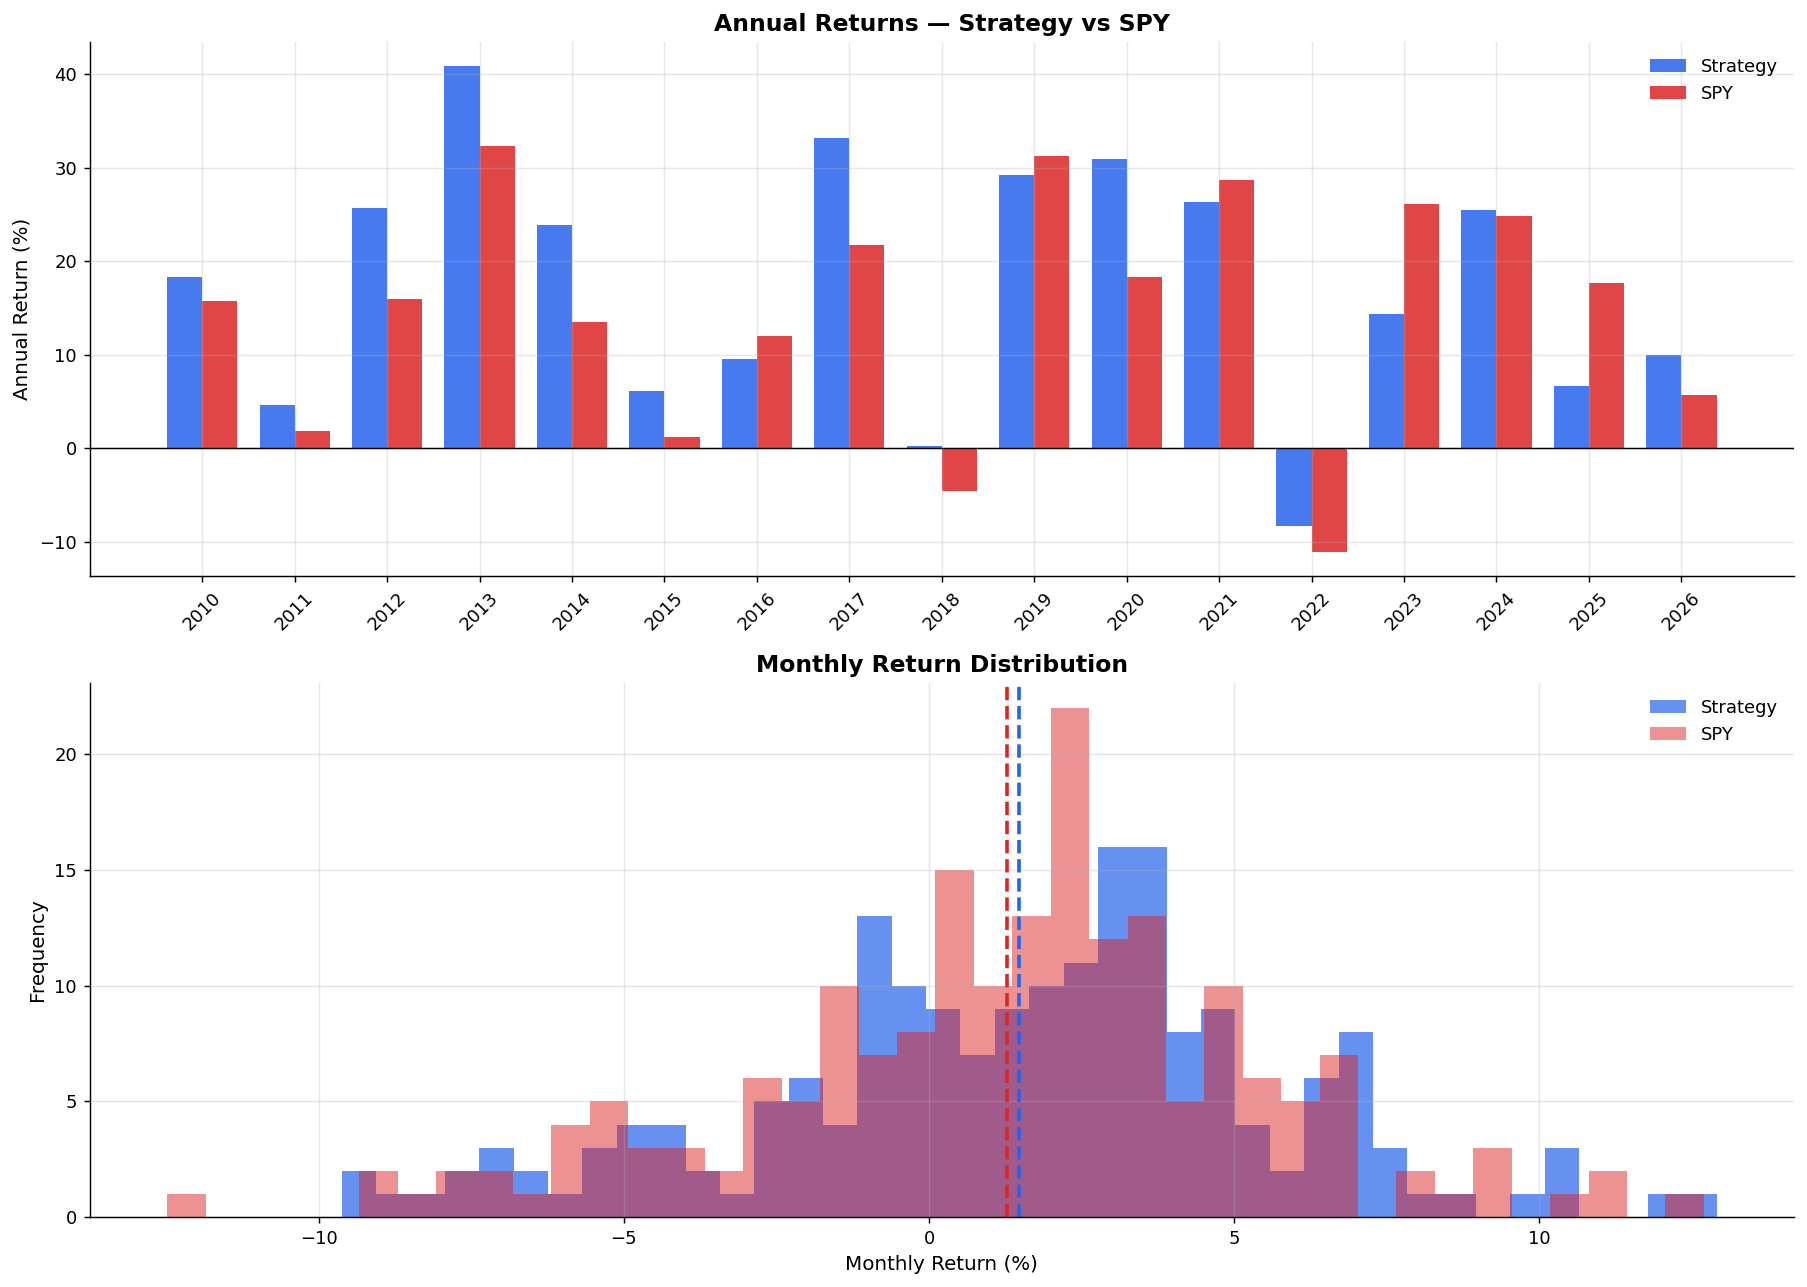

═══════════════════════════════════════════════════════
FULL PERIOD SUMMARY  (2010–Present)
═══════════════════════════════════════════════════════
           Metric Strategy     SPY
     Total Return  1290.4%  842.1%
             CAGR   18.09%  15.22%
       Annual Vol   14.56%  14.36%
     Sharpe Ratio    0.952   0.790
    Sortino Ratio    1.491   1.150
     Max Drawdown  -17.55% -19.45%
     Calmar Ratio    1.031   0.783
         Win Rate    66.3%   68.9%
         Skewness   -0.275  -0.319
  Excess Kurtosis    0.235   0.571
Information Ratio    0.395       —
   Tracking Error    6.36%       —


In [91]:
full_strat_metrics = performance_metrics(full_strat, label='Strategy (Full)')
full_bench_metrics = performance_metrics(full_bench, label='SPY (Full)')

# ── Information Ratio ──
active_returns = full_strat - full_bench.loc[full_strat.index]
info_ratio     = active_returns.mean() / active_returns.std() * np.sqrt(12)

# ── Tracking error ──
tracking_error = active_returns.std() * np.sqrt(12)

# ── Annual returns bar chart ──
annual_strat = full_strat.groupby(full_strat.index.year).apply(
    lambda x: (1 + x).prod() - 1)
annual_bench = full_bench.groupby(full_bench.index.year).apply(
    lambda x: (1 + x).prod() - 1)

years       = sorted(set(annual_strat.index).intersection(annual_bench.index))
x           = np.arange(len(years))
width       = 0.38

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Annual bars
bars_s = axes[0].bar(x - width/2, [annual_strat.get(y, 0)*100 for y in years],
                      width, label='Strategy', color=COLORS['strategy'], alpha=0.85)
bars_b = axes[0].bar(x + width/2, [annual_bench.get(y, 0)*100 for y in years],
                      width, label='SPY', color=COLORS['benchmark'], alpha=0.85)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(years, rotation=45)
axes[0].set_ylabel('Annual Return (%)')
axes[0].set_title('Annual Returns — Strategy vs SPY', fontweight='bold')
axes[0].legend(frameon=False)

# Monthly return distribution
axes[1].hist(full_strat * 100, bins=40, alpha=0.7, color=COLORS['strategy'],
             label='Strategy', edgecolor='none')
axes[1].hist(full_bench * 100, bins=40, alpha=0.5, color=COLORS['benchmark'],
             label='SPY', edgecolor='none')
axes[1].axvline(full_strat.mean()*100, color=COLORS['strategy'], lw=2, ls='--')
axes[1].axvline(full_bench.mean()*100, color=COLORS['benchmark'], lw=2, ls='--')
axes[1].set_xlabel('Monthly Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Monthly Return Distribution', fontweight='bold')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig('annual_returns_and_distribution.png', bbox_inches='tight')
plt.show()

# ── Final summary table ──
full_table = pd.DataFrame({
    'Metric':   metric_keys + ['Information Ratio', 'Tracking Error'],
    'Strategy': [full_strat_metrics[k] for k in metric_keys] +
                [f'{info_ratio:.3f}', f'{tracking_error:.2%}'],
    'SPY':      [full_bench_metrics[k] for k in metric_keys] + ['—', '—'],
})

print('═' * 55)
print('FULL PERIOD SUMMARY  (2010–Present)')
print('═' * 55)
print(full_table.to_string(index=False))


## 14. Limitations & Further Work

### Known Limitations

| Issue | Estimated Impact | Production Fix |
|-------|-----------------|----------------|
| **Survivorship bias** | ~1–2% p.a. overstatement (academic consensus for large-cap). Bankrupt and delisted stocks are absent from the universe entirely. | Point-in-time constituent database |
| **Look-ahead bias in fundamentals** | Pre-2021 Value and Quality use today's P/B and ROE back-applied to the full history. This is a data issue. Quality's single-factor Sharpe of ~1.10 is likely inflated by this. | Quarterly filing dates with a 60-day publication lag applied throughout |
| **Factor diversification overstated** | Cross-sectional signal correlations are near zero, but factor portfolio return correlations are 0.77–0.88. The four factors mostly select the same large-caps, so the diversification benefit is real but modest. | Broader universe (Russell 3000), explicit sector neutrality constraints, or orthogonal factor construction |
| **Regime sensitivity** | Rolling 3Y Sharpe fell to ~0.35 in 2023–2024, suggesting meaningful exposure to rate/macro environment. Full-period headline numbers mask this variability. | Dynamic factor weighting using macro regime signals (yield curve slope, credit spreads) |
| **Transaction cost model** | 10 bps one-way is reasonable for institutional small-scale execution but will break down for larger portfolios depending on position sizes. | Almgren-Chriss or similar market impact model that scales TC with position size and ADV |
| **Long-only constraint** | The bottom 20% is left unexploited. A long/short extension would likely raise Sharpe and reduce market beta, but requires a broader universe to make the short leg economically viable. | Extend universe to Russell 3000 and add a short leg with realistic borrow cost estimation |

### Extensions

The single highest-priority fix is the fundamentals data problem, with point-in-time only data. It is genuinely hard to know whether Value and Quality are contributing real alpha or just picking up the forward-knowledge of which companies survived until this is corrected. Momentum and Low Volatility rest on price data only and are unaffected by this.

Beyond the data quality fix, the an interesting extension is dynamic factor weighting: the walk-forward analysis shows that the composite's Sharpe varies considerably across macro regimes, which suggests there is exploitable information in the regime environment that a static weight scheme leaves on the table.

### Honest Summary

The long-only strategy delivers genuine OOS outperformance with better drawdown control than SPY. But the headline numbers almost certainly overstate true alpha by 1–3% p.a. once survivorship bias and look-ahead bias are cut out. The credible sources of alpha here are Momentum (clean, price-based, well-documented) and Low Volatility (same). Value and Quality as implemented are illustrative rather than production-ready. Higher quality data is required to check this strategies validity.

In [92]:
# ── Saved output files ────────────────────────────────────────────────────────
output_files = [
    'factor_correlations.png',
    'in-sample_cumulative_returns_(2010-2018).png',
    'out-of-sample_cumulative_returns_(2019-present).png',
    'walk_forward_analysis.png',
    'monte_carlo_oos.png',
    'factor_attribution.png',
    'annual_returns_and_distribution.png',
]
print('Output files:')
for f in output_files:
    print(f'  {f}')

Output files:
  factor_correlations.png
  in-sample_cumulative_returns_(2010-2018).png
  out-of-sample_cumulative_returns_(2019-present).png
  walk_forward_analysis.png
  monte_carlo_oos.png
  factor_attribution.png
  annual_returns_and_distribution.png
